# Eval Results Analysis
Deep-dive into model performance, skills errors, and field-level diagnostics.

**Run from the project root** or set `RESULTS_DIR` below.

In [ ]:
import json, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from collections import Counter, defaultdict

plt.rcParams.update({"figure.dpi": 130, "font.size": 11})
sns.set_theme(style="whitegrid", palette="husl")

# ── Load latest results file ──────────────────────────────────────────────────
RESULTS_DIR = Path("results")  # relative to eval/
result_files = sorted(RESULTS_DIR.glob("*.json"), key=lambda p: p.stat().st_mtime)
result_files = [f for f in result_files if "checkpoint" not in f.name]
RESULTS_FILE = result_files[-1]  # most recent
print(f"Loading: {RESULTS_FILE.name}")

with open(RESULTS_FILE) as f:
    data = json.load(f)

TEACHER = data["teacher_model"]
ALL_MODELS = data["student_models"]
JOBS = data["jobs"]
AGGREGATE = data["aggregate"]
print(f"Teacher : {TEACHER}")
print(f"Students: {len(ALL_MODELS)}")
print(f"Jobs    : {len(JOBS)}")

Loading: 20260220_151848_openai-gpt-5_2_7models.json
Teacher : openai/gpt-5.2
Students: 7
Jobs    : 294


In [ ]:
# ── Constants & helpers ───────────────────────────────────────────────────────
SCORED_FIELDS = [
    "work_mode",
    "canada_eligible",
    "seniority",
    "role_family",
    "visa_sponsorship",
    "required_skills",
    "preferred_skills",
    "red_flags",
    "years_exp_min",
    "years_exp_max",
    "salary_min",
    "salary_max",
    "salary_currency",
]
LIST_FIELDS = ["required_skills", "preferred_skills", "red_flags"]
CAT_FIELDS = [
    "work_mode",
    "canada_eligible",
    "seniority",
    "role_family",
    "visa_sponsorship",
]
NUM_FIELDS = [
    "years_exp_min",
    "years_exp_max",
    "salary_min",
    "salary_max",
    "salary_currency",
]

_SKILL_ALIASES = {
    "js": "javascript",
    "ts": "typescript",
    "k8s": "kubernetes",
    "postgres": "postgresql",
    "torch": "pytorch",
    "tf": "tensorflow",
    "gcp": "google cloud",
    "aws": "amazon web services",
    "azure": "microsoft azure",
}


def short_name(m):
    return m.split("/")[-1].replace("-instruct", "").replace("-thinking-2507", "")


def parse_list(v):
    """Parse a JSON-encoded skill list or return empty list."""
    if not v:
        return []
    if isinstance(v, list):
        return v
    try:
        r = json.loads(v)
        return r if isinstance(r, list) else []
    except Exception:
        return []


def normalize_skill(s):
    s = s.lower().strip()
    s = re.sub(r"\s*\(.*?\)\s*$", "", s).strip()
    return _SKILL_ALIASES.get(s, s)


def normalize_skills(lst):
    return {normalize_skill(s) for s in lst if s}


# Filter to only models that actually ran
MODELS = [m for m in ALL_MODELS if m in AGGREGATE]
MODEL_LABELS = [short_name(m) for m in MODELS]
PALETTE = dict(zip(MODELS, sns.color_palette("husl", len(MODELS))))
print("Active models:", MODEL_LABELS)

Active models: ['gemma-3-27b-it', 'gpt-oss-120b', 'mistral-small-3.2-24b', 'qwen3-30b-a3b', 'llama-4-scout']


In [ ]:
# ── Build flat DataFrame: one row per (job, model) ────────────────────────────
rows = []
for job in JOBS:
    for model in MODELS:
        student = job["students"].get(model, {})
        if not student or not student.get("scores"):
            continue
        row = {
            "job_id": job["id"],
            "company": job["company"],
            "title": job["title"],
            "segment": job.get("segment", "core"),
            "model": model,
            "model_short": short_name(model),
        }
        row.update(student["scores"])
        rows.append(row)

df = pd.DataFrame(rows)
print(f"DataFrame shape: {df.shape}")
df.head(2)

DataFrame shape: (1294, 26)


,job_id,company,title,segment,model,model_short,work_mode,canada_eligible,seniority,role_family,...,preferred_skills__r,red_flags,red_flags__p,red_flags__r,years_exp_min,years_exp_max,salary_min,salary_max,salary_currency,overall
0,db-001,Databricks,AI Engineer - FDE (Forward Deployed Engineer),salary_disclosed,google/gemma-3-27b-it,gemma-3-27b-it,1.0,1.00,0.75,1.0,...,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.886961
1,db-001,Databricks,AI Engineer - FDE (Forward Deployed Engineer),salary_disclosed,openai/gpt-oss-120b,gpt-oss-120b,1.0,0.25,0.00,1.0,...,0.5,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.790724


---
## 1. Overall Model Leaderboard

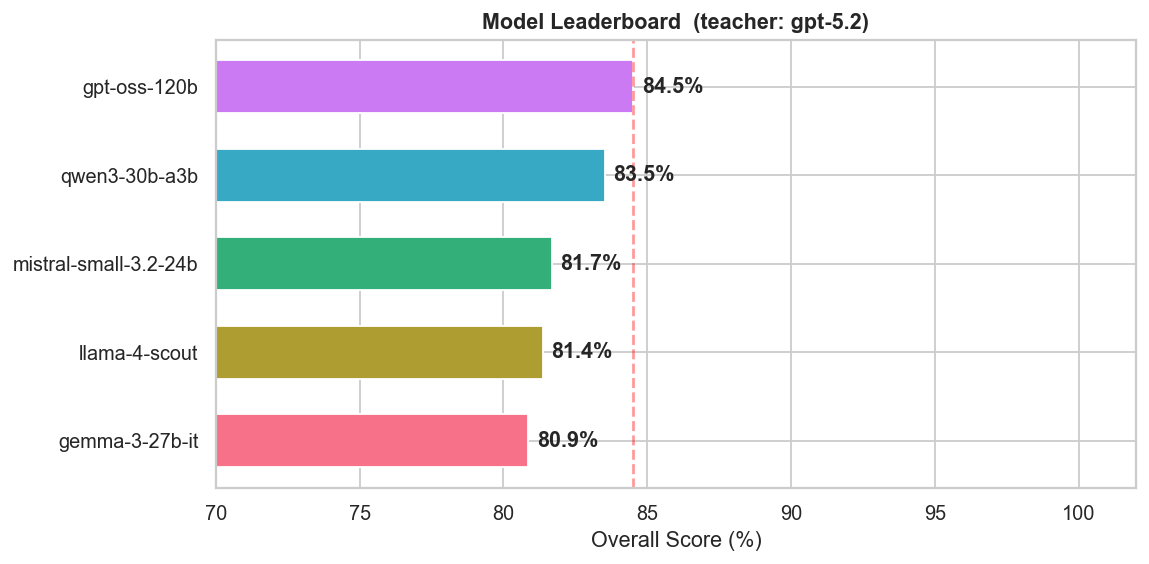

In [ ]:
overall = pd.DataFrame(
    [{"model": short_name(m), "overall": AGGREGATE[m]["overall"] * 100} for m in MODELS]
).sort_values("overall", ascending=True)

fig, ax = plt.subplots(figsize=(9, 0.6 * len(MODELS) + 1.5))
bars = ax.barh(
    overall["model"],
    overall["overall"],
    color=[PALETTE[m] for m in MODELS if short_name(m) in overall["model"].values],
    edgecolor="white",
    height=0.6,
)
for bar, (_, row) in zip(bars, overall.iterrows()):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{row['overall']:.1f}%",
        va="center",
        fontweight="bold",
    )
ax.set_xlim(70, 102)
ax.set_xlabel("Overall Score (%)")
ax.set_title(f"Model Leaderboard  (teacher: {short_name(TEACHER)})", fontweight="bold")
ax.axvline(
    overall["overall"].max(), color="red", linestyle="--", alpha=0.4, label="Best"
)
plt.tight_layout()
plt.show()

---
## 2. Field-by-Field Heatmap

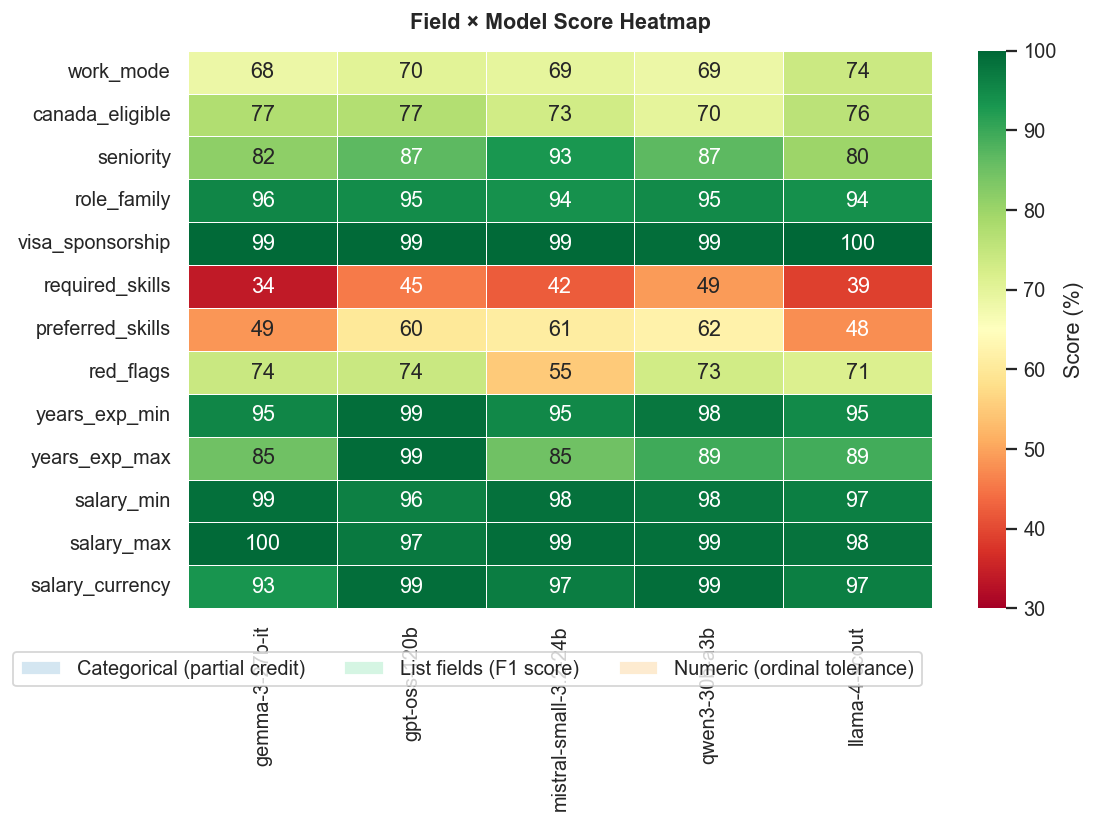

In [ ]:
heat_data = pd.DataFrame(
    {
        short_name(m): [AGGREGATE[m].get(f, np.nan) * 100 for f in SCORED_FIELDS]
        for m in MODELS
    },
    index=SCORED_FIELDS,
)

fig, ax = plt.subplots(figsize=(max(9, len(MODELS) * 1.5), 6.5))
sns.heatmap(
    heat_data,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn",
    vmin=30,
    vmax=100,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Score (%)"},
    ax=ax,
)
ax.set_title("Field × Model Score Heatmap", fontweight="bold", pad=12)
ax.set_xlabel("")
ax.set_ylabel("")

# Mark field type with left-side color band
field_colors = {f: "#d4e6f1" for f in CAT_FIELDS}
field_colors.update({f: "#d5f5e3" for f in LIST_FIELDS})
field_colors.update({f: "#fdebd0" for f in NUM_FIELDS})

legend_elements = [
    mpatches.Patch(facecolor="#d4e6f1", label="Categorical (partial credit)"),
    mpatches.Patch(facecolor="#d5f5e3", label="List fields (F1 score)"),
    mpatches.Patch(facecolor="#fdebd0", label="Numeric (ordinal tolerance)"),
]
ax.legend(
    handles=legend_elements,
    loc="upper right",
    bbox_to_anchor=(1.0, -0.06),
    ncol=3,
    frameon=True,
)
plt.tight_layout()
plt.show()

---
## 3. Skills: Precision / Recall / F1 per Model

Precision = of the skills the model extracted, how many match the teacher?  
Recall = of the skills the teacher extracted, how many did the model find?

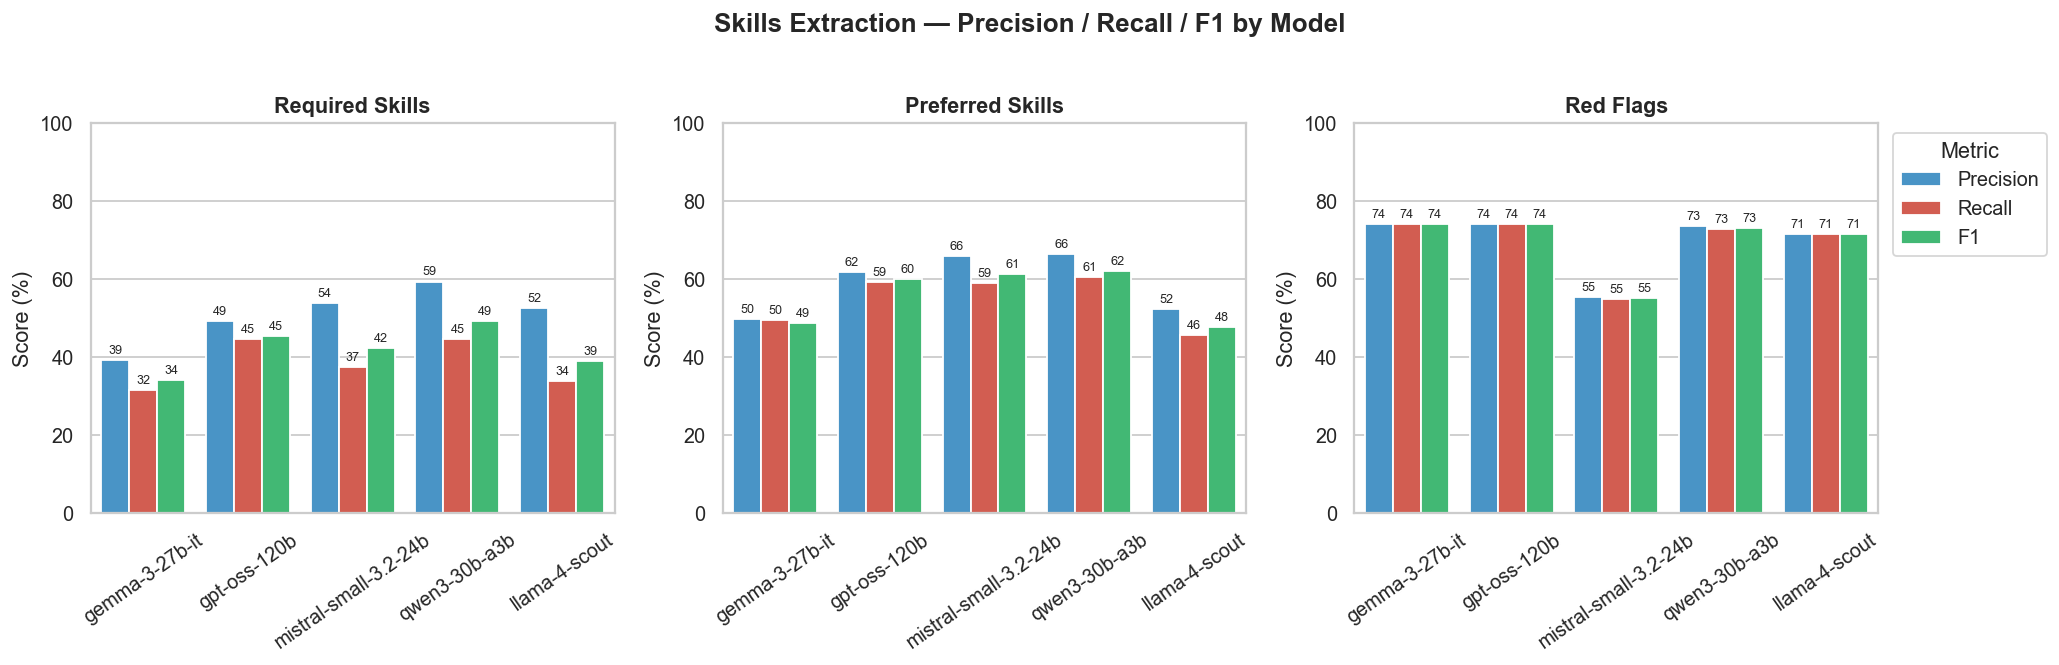

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for ax, field in zip(axes, LIST_FIELDS):
    pr_data = []
    for m in MODELS:
        p = AGGREGATE[m].get(f"{field}__p", 0) * 100
        r = AGGREGATE[m].get(f"{field}__r", 0) * 100
        f1 = AGGREGATE[m].get(field, 0) * 100
        pr_data.append({"model": short_name(m), "Precision": p, "Recall": r, "F1": f1})
    pr_df = pd.DataFrame(pr_data).melt("model", var_name="Metric", value_name="Score")

    sns.barplot(
        data=pr_df,
        x="model",
        y="Score",
        hue="Metric",
        palette={"Precision": "#3498db", "Recall": "#e74c3c", "F1": "#2ecc71"},
        ax=ax,
    )
    ax.set_title(field.replace("_", " ").title(), fontweight="bold")
    ax.set_ylim(0, 100)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=35)
    ax.set_ylabel("Score (%)")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.0f", fontsize=7, padding=2)

axes[0].get_legend().remove()
axes[2].legend(title="Metric", bbox_to_anchor=(1.01, 1), loc="upper left")
axes[1].get_legend().remove()
fig.suptitle(
    "Skills Extraction — Precision / Recall / F1 by Model", fontweight="bold", y=1.02
)
plt.tight_layout()
plt.show()

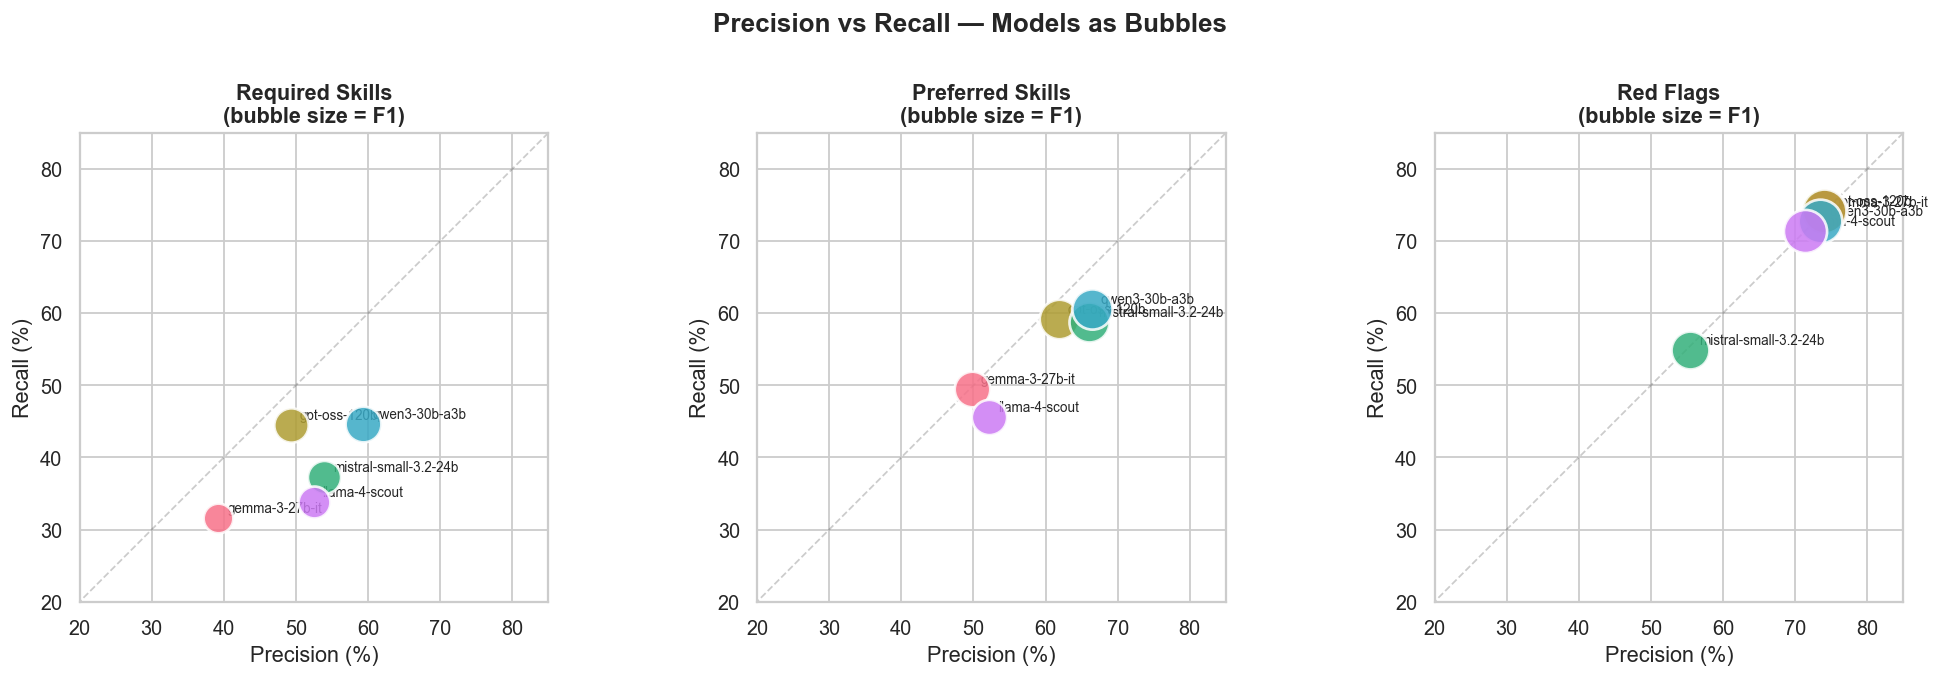

In [ ]:
# Precision vs Recall scatter — bubble size = F1
fig, axes = plt.subplots(1, len(LIST_FIELDS), figsize=(16, 5))

for ax, field in zip(axes, LIST_FIELDS):
    for m in MODELS:
        p = AGGREGATE[m].get(f"{field}__p", 0) * 100
        r = AGGREGATE[m].get(f"{field}__r", 0) * 100
        f1 = AGGREGATE[m].get(field, 0) * 100
        color = PALETTE[m]
        ax.scatter(
            p,
            r,
            s=f1 * 8,
            color=color,
            edgecolors="white",
            linewidth=1.5,
            label=short_name(m),
            alpha=0.85,
            zorder=5,
        )
        ax.annotate(
            short_name(m),
            (p, r),
            fontsize=7.5,
            xytext=(5, 3),
            textcoords="offset points",
        )
    ax.plot([0, 100], [0, 100], "k--", alpha=0.2, linewidth=1, label="P=R line")
    ax.set_xlim(20, 85)
    ax.set_ylim(20, 85)
    ax.set_xlabel("Precision (%)")
    ax.set_ylabel("Recall (%)")
    ax.set_title(
        f'{field.replace("_", " ").title()}\n(bubble size = F1)', fontweight="bold"
    )
    ax.set_aspect("equal")

fig.suptitle("Precision vs Recall — Models as Bubbles", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Skills Error Analysis — What Does the Teacher Extract vs Models?

For each skill the teacher extracted across all jobs:  
- **False Negative rate** = how often does the model *miss* this skill?  
- **False Positive rate** = what skills does the model add that the teacher didn't?  

In [ ]:
def build_skill_error_df(model, field="required_skills", top_n=30):
    """
    Returns a DataFrame with columns:
      skill | teacher_count | model_count | fn_count | fp_count | fn_rate
    for the given model and field.
    """
    teacher_freq = Counter()
    fn_freq = Counter()  # skills teacher has that model misses
    fp_freq = Counter()  # skills model adds that teacher doesn't have

    for job in JOBS:
        student = job["students"].get(model, {})
        if not student or not student.get("output"):
            continue
        t_raw = parse_list(job["teacher"].get(field))
        s_raw = parse_list(student["output"].get(field))
        t_skills = normalize_skills(t_raw)
        s_skills = normalize_skills(s_raw)
        for sk in t_skills:
            teacher_freq[sk] += 1
            if sk not in s_skills:
                fn_freq[sk] += 1
        for sk in s_skills - t_skills:
            fp_freq[sk] += 1

    top_skills = [sk for sk, _ in teacher_freq.most_common(top_n)]
    records = []
    for sk in top_skills:
        tc = teacher_freq[sk]
        fn = fn_freq[sk]
        records.append(
            {
                "skill": sk,
                "teacher_count": tc,
                "fn_count": fn,
                "fn_rate": fn / tc if tc else 0,
                "fp_count": fp_freq.get(sk, 0),
            }
        )
    return pd.DataFrame(records)


FOCUS_MODEL = (
    [m for m in MODELS if "gpt-oss" in m][0]
    if any("gpt-oss" in m for m in MODELS)
    else MODELS[0]
)
print(f"Focus model: {FOCUS_MODEL}")

Focus model: openai/gpt-oss-120b


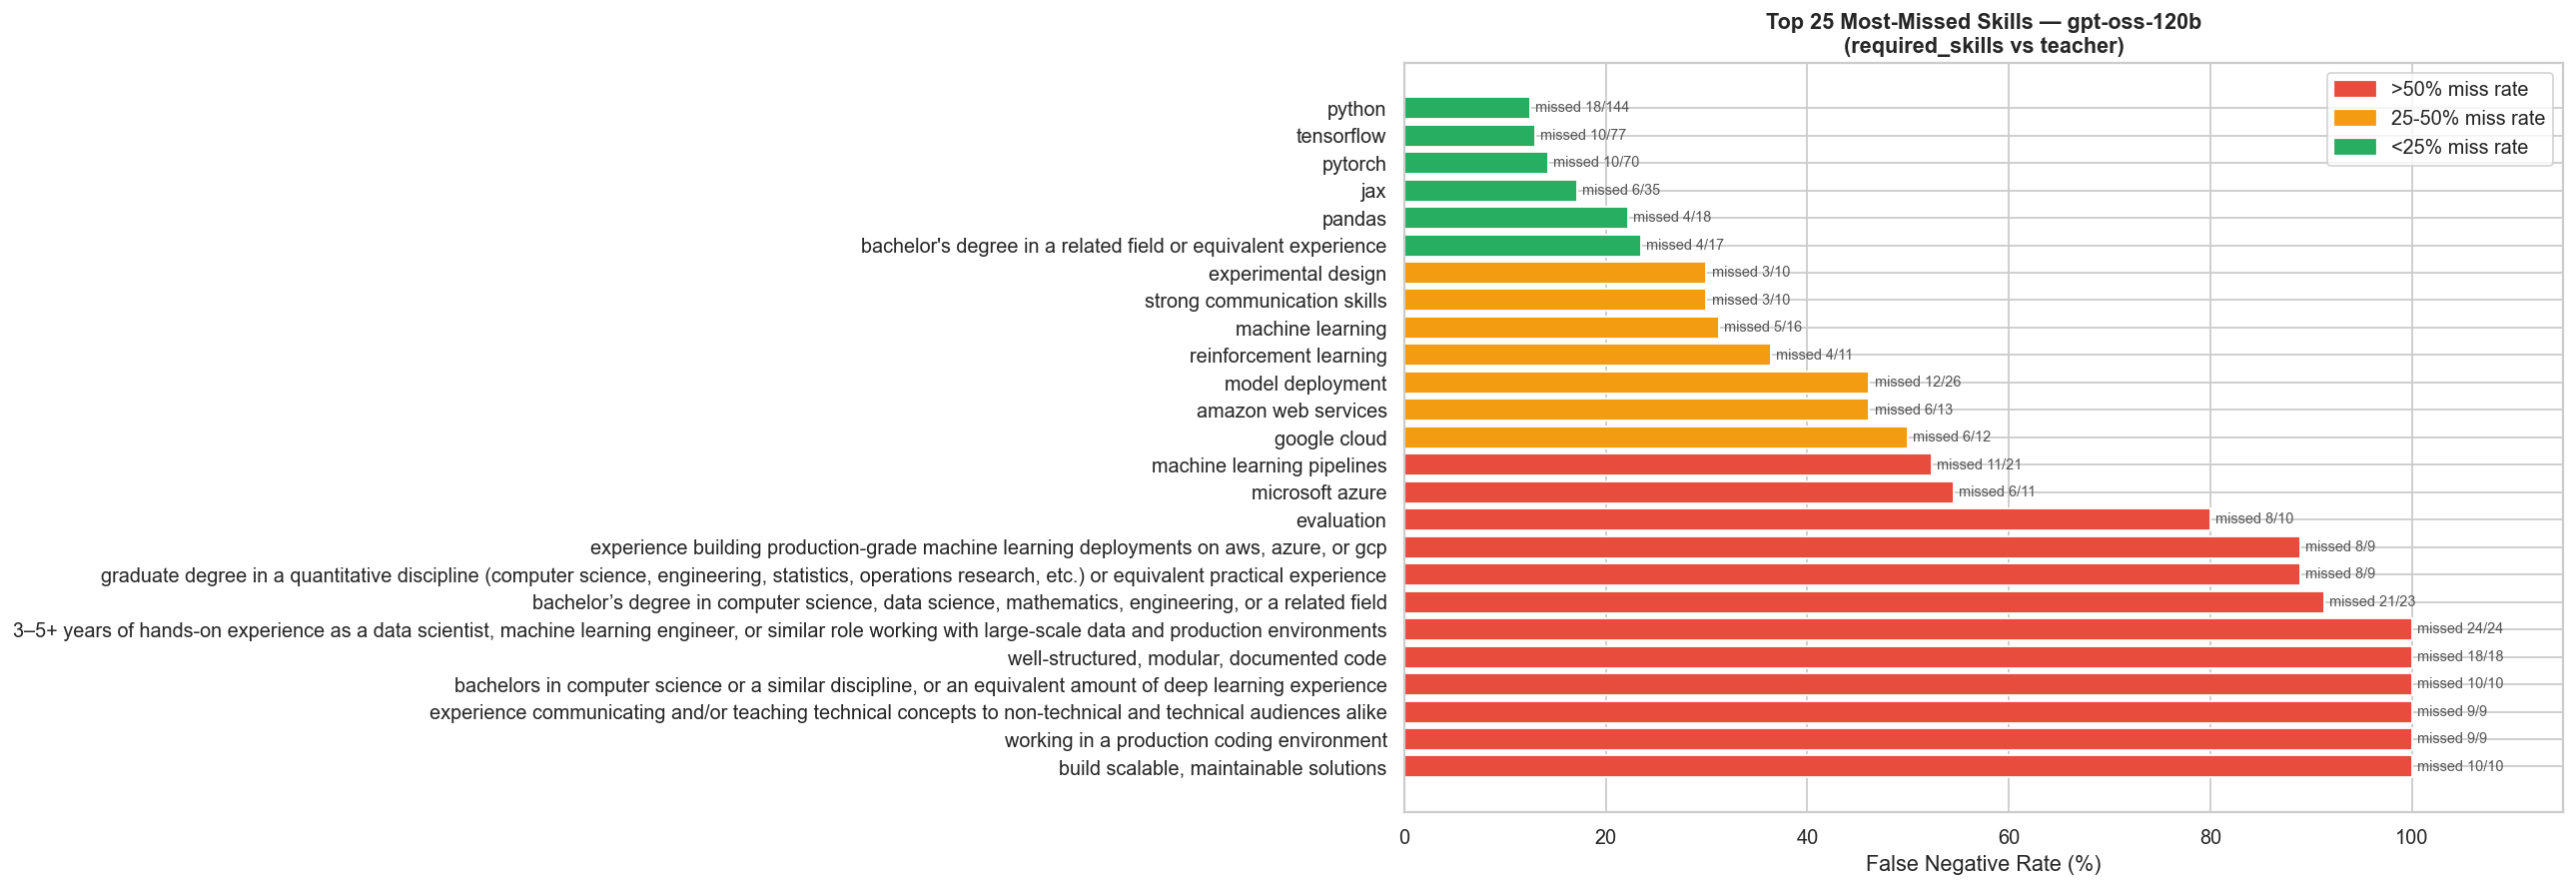

In [ ]:
# Most-missed skills (false negatives) — required_skills
err_df = build_skill_error_df(FOCUS_MODEL, "required_skills", top_n=40)
err_df_sorted = err_df.sort_values("fn_rate", ascending=False).head(25)

fig, ax = plt.subplots(figsize=(20, 7))
colors_fn = [
    "#e74c3c" if r > 0.5 else "#f39c12" if r > 0.25 else "#27ae60"
    for r in err_df_sorted["fn_rate"]
]
bars = ax.barh(
    err_df_sorted["skill"],
    err_df_sorted["fn_rate"] * 100,
    color=colors_fn,
    edgecolor="white",
)
for bar, (_, row) in zip(bars, err_df_sorted.iterrows()):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"missed {row['fn_count']}/{row['teacher_count']}",
        va="center",
        fontsize=8,
        color="#555",
    )
ax.set_xlim(0, 115)
ax.set_xlabel("False Negative Rate (%)")
ax.set_title(
    f"Top 25 Most-Missed Skills — {short_name(FOCUS_MODEL)}\n(required_skills vs teacher)",
    fontweight="bold",
)

legend_els = [
    mpatches.Patch(color="#e74c3c", label=">50% miss rate"),
    mpatches.Patch(color="#f39c12", label="25-50% miss rate"),
    mpatches.Patch(color="#27ae60", label="<25% miss rate"),
]
ax.legend(handles=legend_els, loc="upper right", bbox_to_anchor=(1.0, 1.0))
plt.tight_layout()
plt.show()

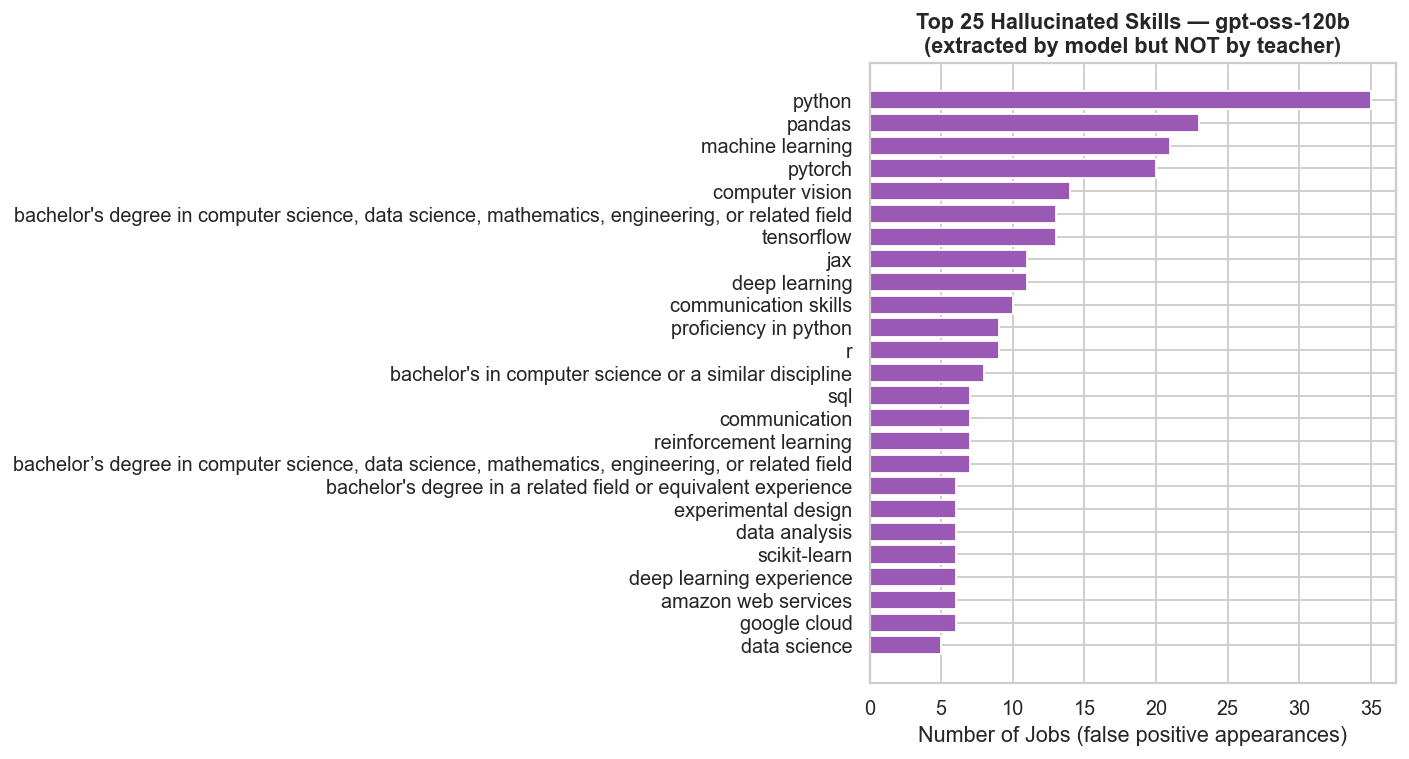

In [ ]:
# Skills the model HALLUCINATES most (false positives — in model but not teacher)
fp_data = []
for job in JOBS:
    student = job["students"].get(FOCUS_MODEL, {})
    if not student or not student.get("output"):
        continue
    t_skills = normalize_skills(parse_list(job["teacher"].get("required_skills")))
    s_skills = normalize_skills(parse_list(student["output"].get("required_skills")))
    fp_data.extend(list(s_skills - t_skills))

fp_counter = Counter(fp_data)
fp_df = pd.DataFrame(fp_counter.most_common(25), columns=["skill", "count"])

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(fp_df["skill"][::-1], fp_df["count"][::-1], color="#9b59b6", edgecolor="white")
ax.set_xlabel("Number of Jobs (false positive appearances)")
ax.set_title(
    f"Top 25 Hallucinated Skills — {short_name(FOCUS_MODEL)}\n(extracted by model but NOT by teacher)",
    fontweight="bold",
)
plt.tight_layout()
plt.show()

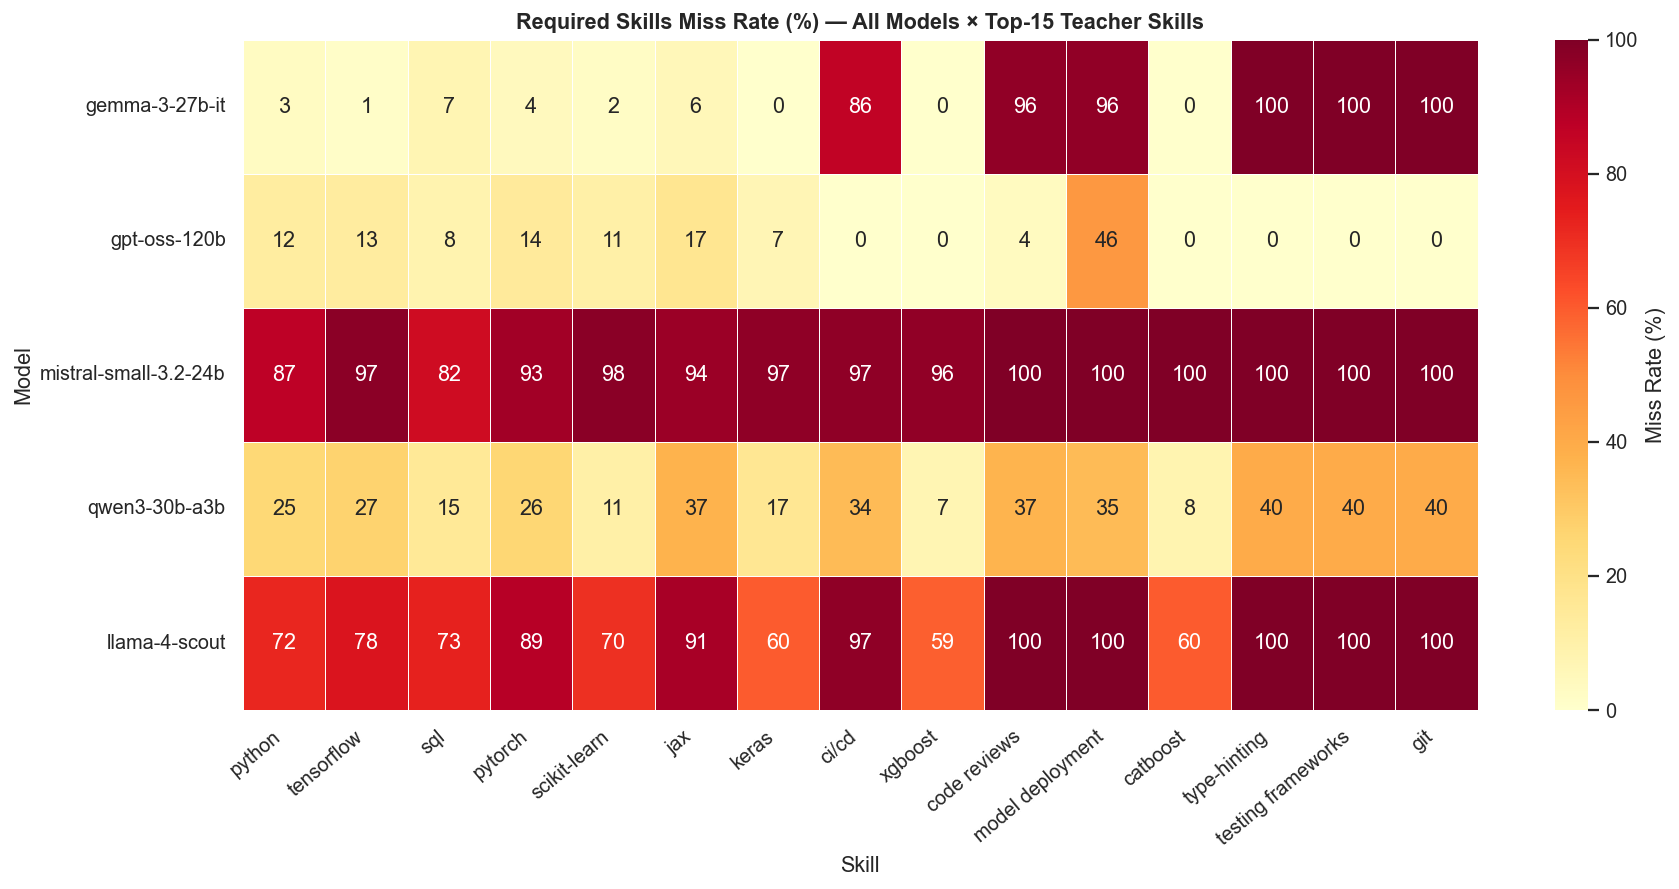

In [ ]:
# Skills Miss-Rate comparison across ALL models
fig, ax = plt.subplots(figsize=(14, 7))

top_teacher_skills = [
    sk
    for sk, _ in Counter(
        [
            sk
            for job in JOBS
            for sk in normalize_skills(
                parse_list(job["teacher"].get("required_skills"))
            )
        ]
    ).most_common(15)
]

miss_matrix = []
for m in MODELS:
    row = []
    for sk in top_teacher_skills:
        total, missed = 0, 0
        for job in JOBS:
            student = job["students"].get(m, {})
            if not student or not student.get("output"):
                continue
            t_skills = normalize_skills(
                parse_list(job["teacher"].get("required_skills"))
            )
            if sk not in t_skills:
                continue
            total += 1
            s_skills = normalize_skills(
                parse_list(student["output"].get("required_skills"))
            )
            if sk not in s_skills:
                missed += 1
        row.append(missed / total * 100 if total else np.nan)
    miss_matrix.append(row)

miss_df = pd.DataFrame(miss_matrix, index=MODEL_LABELS, columns=top_teacher_skills)
sns.heatmap(
    miss_df,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Miss Rate (%)"},
    ax=ax,
)
ax.set_title(
    "Required Skills Miss Rate (%) — All Models × Top-15 Teacher Skills",
    fontweight="bold",
)
ax.set_xlabel("Skill")
ax.set_ylabel("Model")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()

---
## 5. `canada_eligible` Confusion Analysis

The teacher labels jobs as `yes`, `no`, or `unknown`.  
The key question: when does the model get the **boundary between `no` and `unknown`** wrong?

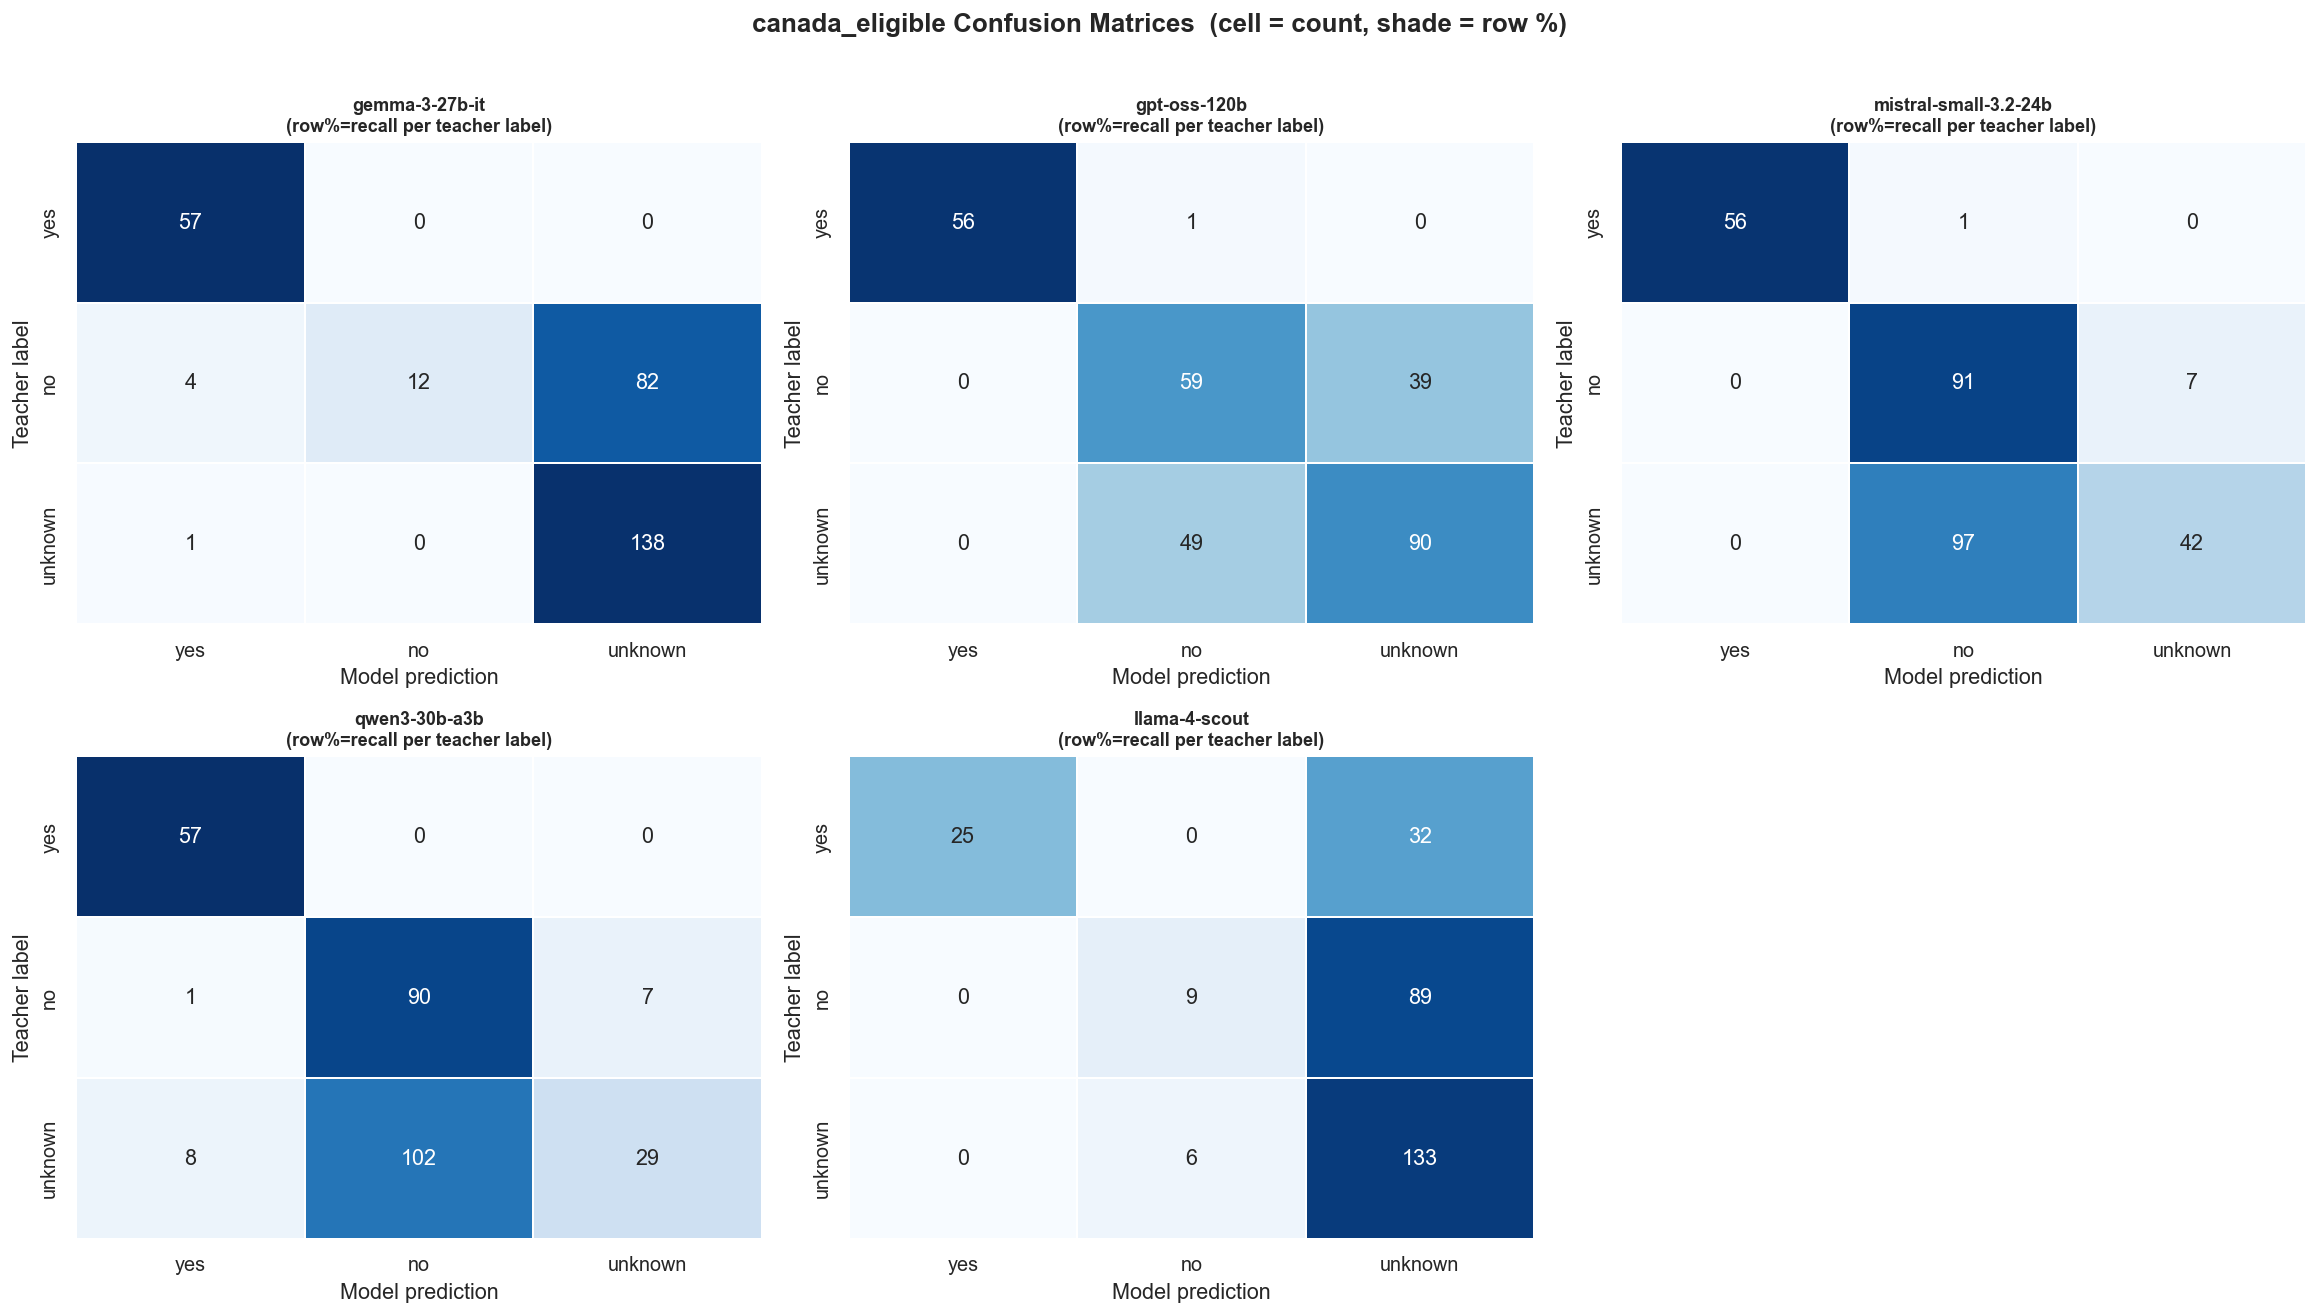

In [ ]:
LABELS = ["yes", "no", "unknown"]


def confusion_matrix_ce(model):
    """Return 3×3 confusion matrix: rows=teacher, cols=model."""
    mat = pd.DataFrame(0, index=LABELS, columns=LABELS)
    for job in JOBS:
        student = job["students"].get(model, {})
        if not student or not student.get("output"):
            continue
        t = str(job["teacher"].get("canada_eligible", "unknown")).lower().strip()
        s = str(student["output"].get("canada_eligible", "unknown")).lower().strip()
        if t not in LABELS:
            t = "unknown"
        if s not in LABELS:
            s = "unknown"
        mat.loc[t, s] += 1
    return mat


n_models = len(MODELS)
ncols = min(3, n_models)
nrows = (n_models + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = np.array(axes).flatten()

for ax, m in zip(axes, MODELS):
    mat = confusion_matrix_ce(m)
    # Normalise by row (teacher label) to show recall per class
    mat_pct = mat.div(mat.sum(axis=1).replace(0, np.nan), axis=0) * 100
    sns.heatmap(
        mat_pct,
        annot=mat.values,
        fmt="d",
        cmap="Blues",
        vmin=0,
        vmax=100,
        linewidths=1,
        linecolor="white",
        cbar=False,
        ax=ax,
    )
    ax.set_title(
        f"{short_name(m)}\n(row%=recall per teacher label)",
        fontweight="bold",
        fontsize=10,
    )
    ax.set_xlabel("Model prediction")
    ax.set_ylabel("Teacher label")

for ax in axes[len(MODELS) :]:
    ax.set_visible(False)

fig.suptitle(
    "canada_eligible Confusion Matrices  (cell = count, shade = row %)",
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()

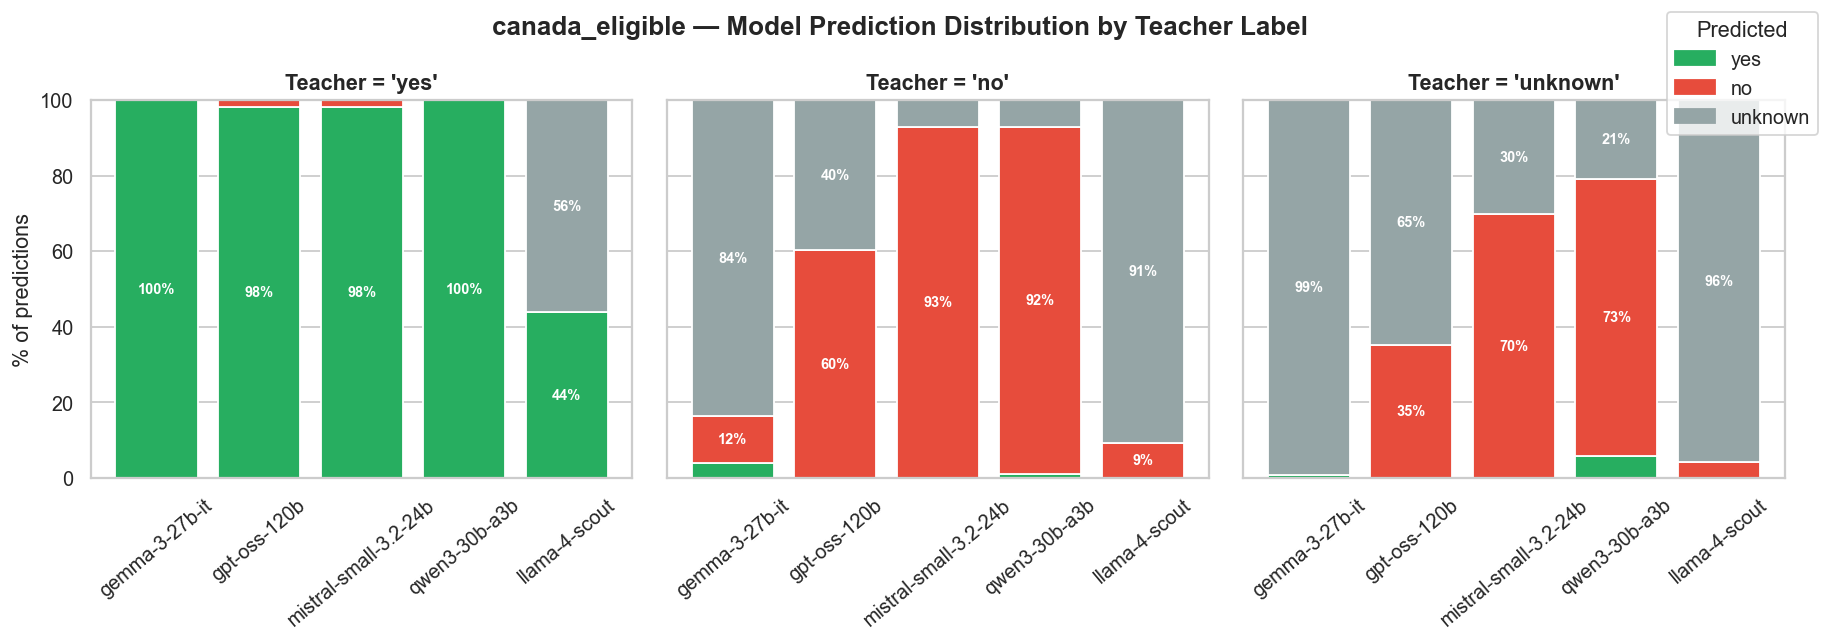

In [ ]:
# Stacked bar: for each teacher label, how do models distribute predictions?
CE_COLORS = {"yes": "#27ae60", "no": "#e74c3c", "unknown": "#95a5a6"}

fig, axes = plt.subplots(1, len(LABELS), figsize=(14, 5), sharey=True)

for ax, true_label in zip(axes, LABELS):
    pred_dist = []
    for m in MODELS:
        row = {"model": short_name(m)}
        total = 0
        counts = {l: 0 for l in LABELS}
        for job in JOBS:
            student = job["students"].get(m, {})
            if not student or not student.get("output"):
                continue
            t = str(job["teacher"].get("canada_eligible", "unknown")).lower().strip()
            if t != true_label:
                continue
            s = str(student["output"].get("canada_eligible", "unknown")).lower().strip()
            if s not in LABELS:
                s = "unknown"
            counts[s] += 1
            total += 1
        if total:
            for lbl in LABELS:
                row[lbl] = counts[lbl] / total * 100
        else:
            for lbl in LABELS:
                row[lbl] = 0
        pred_dist.append(row)

    pd_df = pd.DataFrame(pred_dist).set_index("model")
    bottom = np.zeros(len(MODELS))
    for lbl in LABELS:
        bars = ax.bar(
            pd_df.index,
            pd_df[lbl],
            bottom=bottom,
            color=CE_COLORS[lbl],
            label=lbl,
            edgecolor="white",
        )
        for bar, v in zip(bars, pd_df[lbl]):
            if v > 8:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + bar.get_height() / 2,
                    f"{v:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="white",
                    fontweight="bold",
                )
        bottom += pd_df[lbl].values

    ax.set_title(f"Teacher = '{true_label}'", fontweight="bold")
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", rotation=40)
    ax.set_ylabel("% of predictions" if ax == axes[0] else "")

patches = [mpatches.Patch(color=CE_COLORS[l], label=l) for l in LABELS]
fig.legend(
    handles=patches, title="Predicted", loc="upper right", bbox_to_anchor=(1.01, 1)
)
fig.suptitle(
    "canada_eligible — Model Prediction Distribution by Teacher Label",
    fontweight="bold",
)
plt.tight_layout()
plt.show()

---
## 6. Per-Job Score Distribution

C:\Users\koush\AppData\Local\Temp\ipykernel_8152\2617941591.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x='model_short', y='overall_pct', order=order,


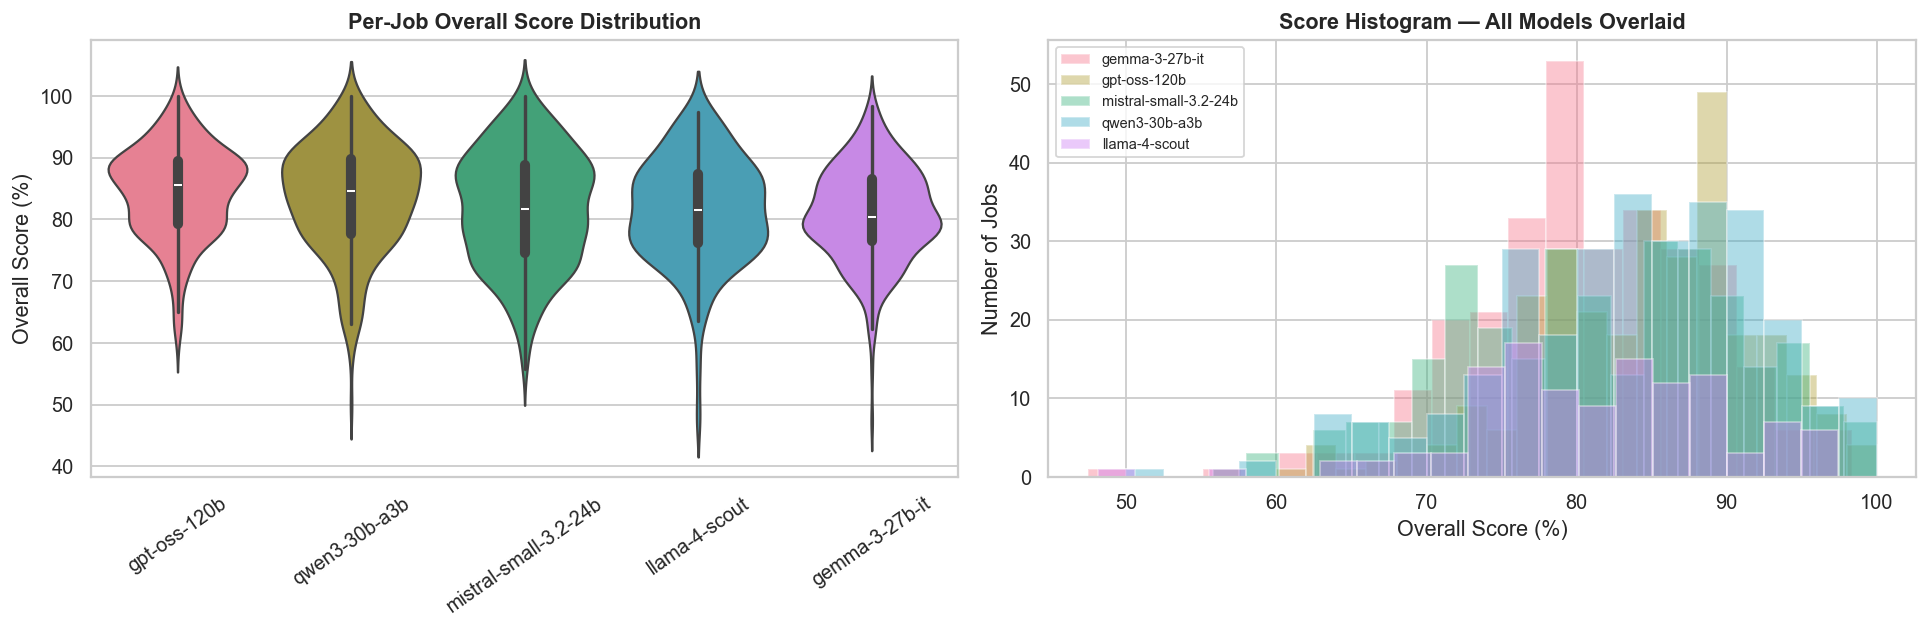

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Violin plot: overall score distribution per model
ax = axes[0]
plot_df = df[df["overall"].notna()].copy()
plot_df["overall_pct"] = plot_df["overall"] * 100
order = (
    plot_df.groupby("model_short")["overall_pct"]
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)
sns.violinplot(
    data=plot_df,
    x="model_short",
    y="overall_pct",
    order=order,
    palette="husl",
    inner="box",
    ax=ax,
)
ax.set_title("Per-Job Overall Score Distribution", fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Overall Score (%)")
ax.tick_params(axis="x", rotation=35)

# Histogram of score gaps vs teacher (teacher = 1.0 per field → we measure student overall)
ax = axes[1]
for m in MODELS:
    model_df = df[df["model"] == m]["overall"].dropna() * 100
    ax.hist(
        model_df,
        bins=20,
        alpha=0.4,
        label=short_name(m),
        color=PALETTE[m],
        edgecolor="white",
    )
ax.set_xlabel("Overall Score (%)")
ax.set_ylabel("Number of Jobs")
ax.set_title("Score Histogram — All Models Overlaid", fontweight="bold")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

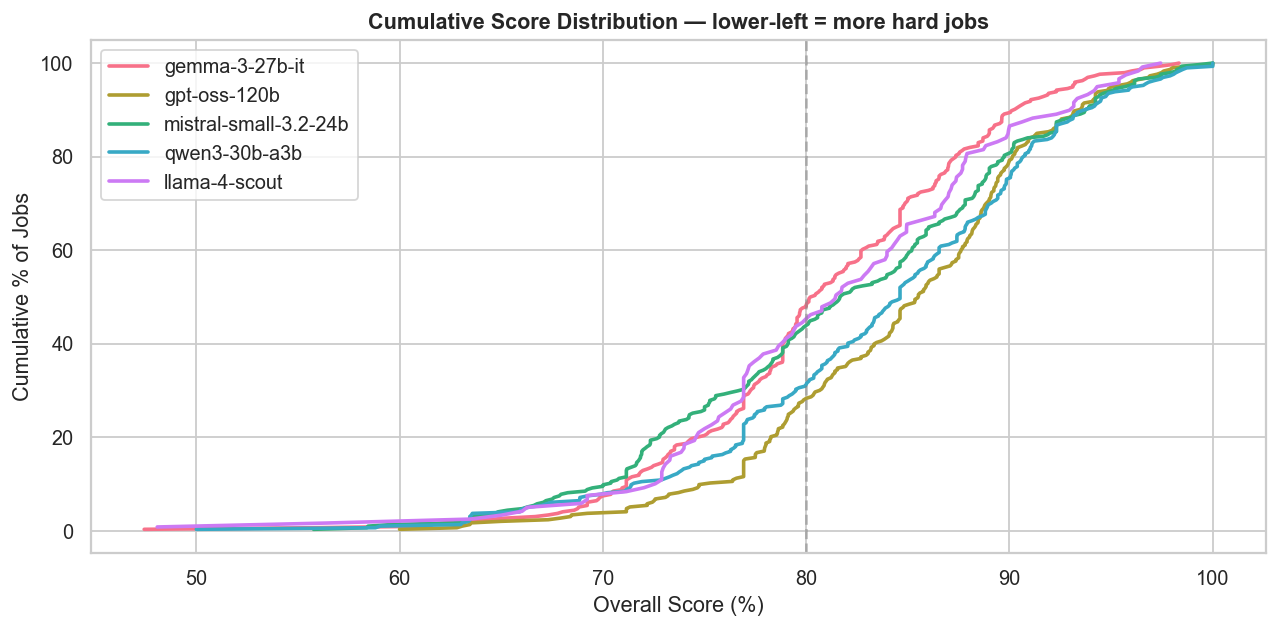

In [ ]:
# Cumulative score distribution — what fraction of jobs score above X?
fig, ax = plt.subplots(figsize=(10, 5))
for m in MODELS:
    model_df = df[df["model"] == m]["overall"].dropna().sort_values() * 100
    cdf = np.arange(1, len(model_df) + 1) / len(model_df) * 100
    ax.plot(model_df.values, cdf, label=short_name(m), color=PALETTE[m], linewidth=2)
ax.set_xlabel("Overall Score (%)")
ax.set_ylabel("Cumulative % of Jobs")
ax.set_title(
    "Cumulative Score Distribution — lower-left = more hard jobs", fontweight="bold"
)
ax.legend()
ax.axvline(80, color="gray", linestyle="--", alpha=0.5, label="80% threshold")
plt.tight_layout()
plt.show()

---
## 7. Worst-Performing Jobs
Jobs where the best model scores lowest — these reveal systematic failure patterns.

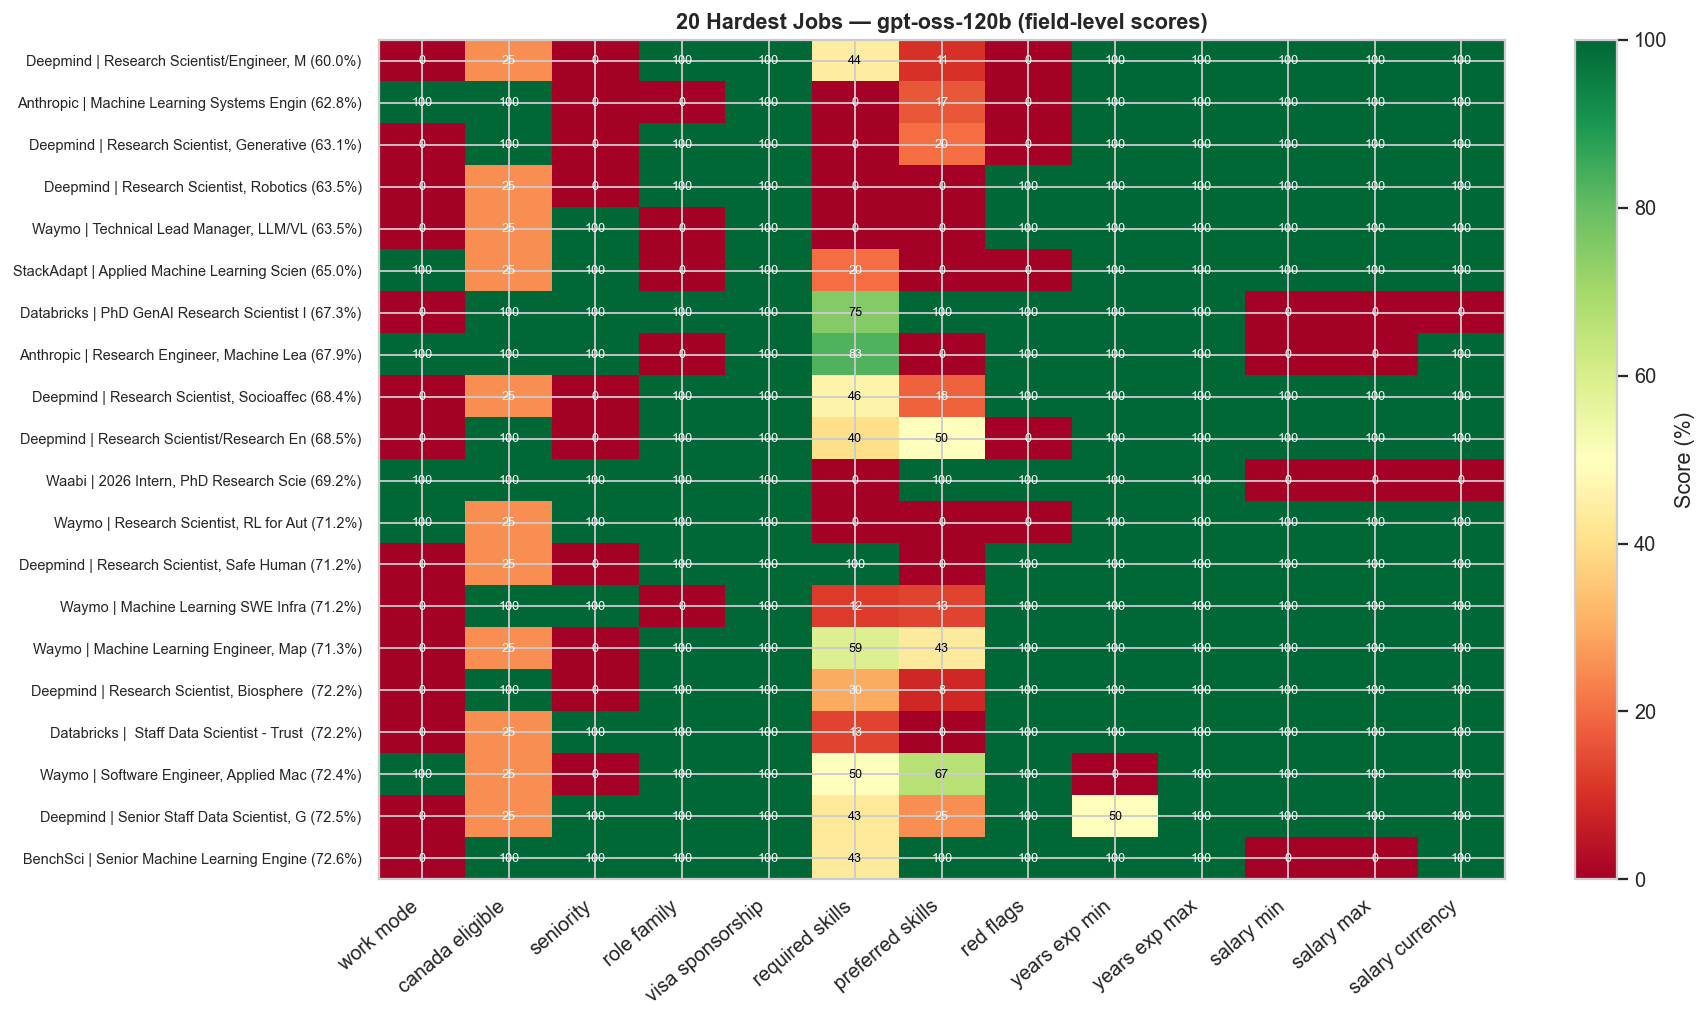

In [ ]:
focus_df = df[df["model"] == FOCUS_MODEL][
    ["job_id", "company", "title", "segment", "overall"] + SCORED_FIELDS
].copy()
focus_df["overall_pct"] = (focus_df["overall"] * 100).round(1)
worst = focus_df.sort_values("overall").head(20)

fig, ax = plt.subplots(figsize=(14, 8))
field_scores = worst[SCORED_FIELDS].values * 100
labels_y = [
    f"{r['company'][:20]} | {r['title'][:30]} ({r['overall_pct']}%)"
    for _, r in worst.iterrows()
]

im = ax.imshow(field_scores, cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")
ax.set_xticks(range(len(SCORED_FIELDS)))
ax.set_xticklabels(
    [f.replace("_", " ") for f in SCORED_FIELDS], rotation=40, ha="right"
)
ax.set_yticks(range(len(labels_y)))
ax.set_yticklabels(labels_y, fontsize=8)
for i in range(field_scores.shape[0]):
    for j in range(field_scores.shape[1]):
        v = field_scores[i, j]
        if not np.isnan(v):
            ax.text(
                j,
                i,
                f"{v:.0f}",
                ha="center",
                va="center",
                fontsize=7,
                color="black" if 30 < v < 80 else "white",
            )
plt.colorbar(im, ax=ax, label="Score (%)")
ax.set_title(
    f"20 Hardest Jobs — {short_name(FOCUS_MODEL)} (field-level scores)",
    fontweight="bold",
)
plt.tight_layout()
plt.show()

---
## 8. Segment Analysis

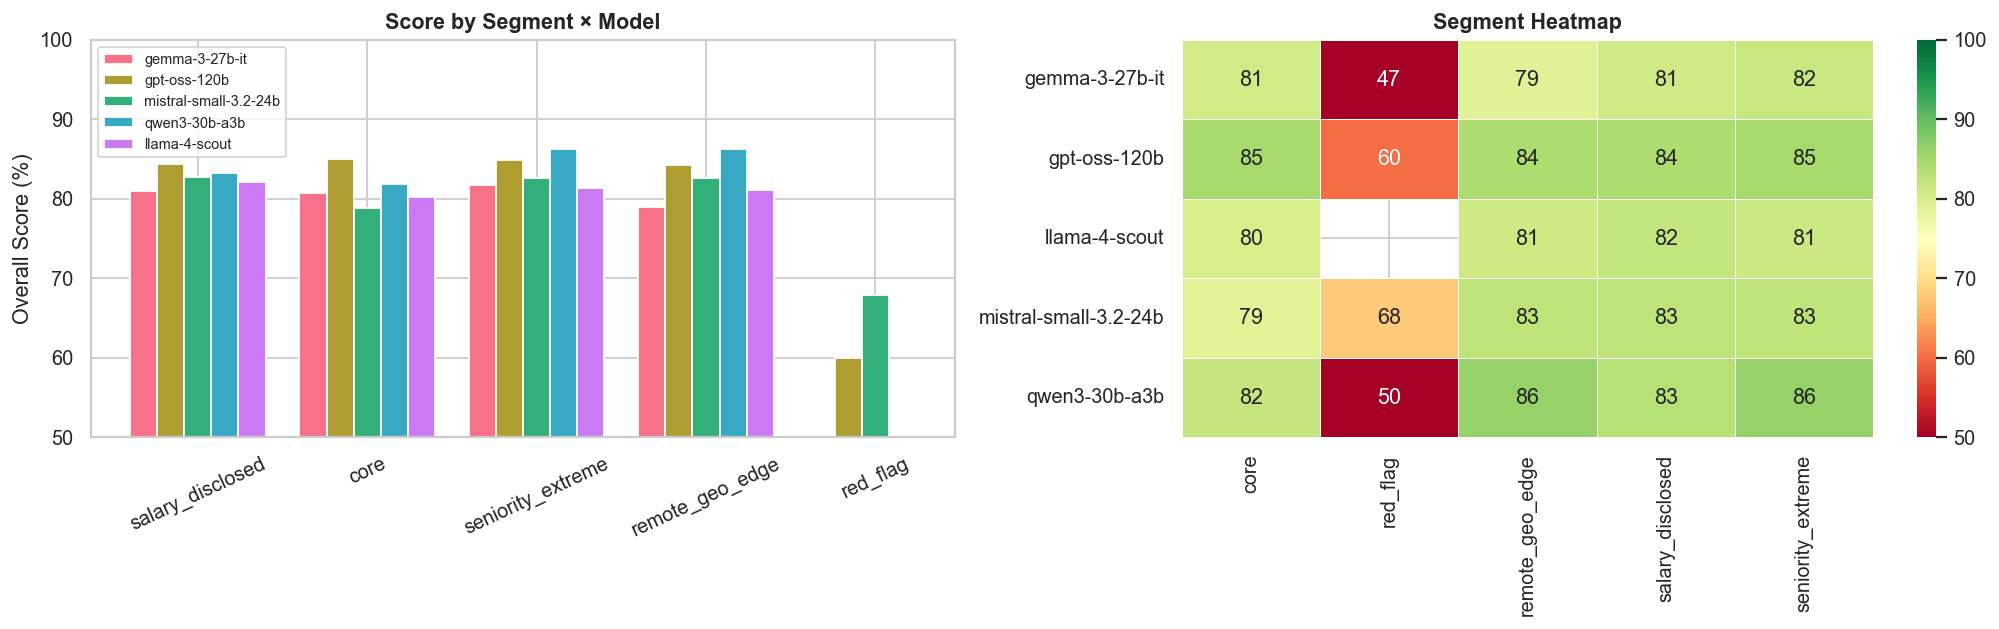


Jobs per segment:
segment
core                  74
red_flag               1
remote_geo_edge       14
salary_disclosed     145
seniority_extreme     59


In [ ]:
seg_data = []
for m in MODELS:
    m_df = df[df["model"] == m]
    for seg in m_df["segment"].unique():
        seg_df = m_df[m_df["segment"] == seg]
        seg_data.append(
            {
                "model": short_name(m),
                "segment": seg,
                "score": seg_df["overall"].mean() * 100,
                "n_jobs": len(seg_df),
            }
        )
seg_df_all = pd.DataFrame(seg_data)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Grouped bar by segment
ax = axes[0]
segments = seg_df_all["segment"].unique()
x = np.arange(len(segments))
width = 0.8 / len(MODELS)
for i, m in enumerate(MODELS):
    m_short = short_name(m)
    vals = [
        seg_df_all[(seg_df_all["model"] == m_short) & (seg_df_all["segment"] == s)][
            "score"
        ].mean()
        for s in segments
    ]
    ax.bar(
        x + i * width - 0.4 + width / 2,
        vals,
        width,
        label=m_short,
        color=PALETTE[m],
        edgecolor="white",
    )
ax.set_xticks(x)
ax.set_xticklabels(segments, rotation=25)
ax.set_ylabel("Overall Score (%)")
ax.set_ylim(50, 100)
ax.set_title("Score by Segment × Model", fontweight="bold")
ax.legend(fontsize=8)

# Segment heatmap
ax = axes[1]
seg_heat = seg_df_all.pivot(index="model", columns="segment", values="score")
sns.heatmap(
    seg_heat,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn",
    vmin=50,
    vmax=100,
    linewidths=0.5,
    linecolor="white",
    ax=ax,
)
ax.set_title("Segment Heatmap", fontweight="bold")
ax.set_ylabel("")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

# Print segment job counts
print("\nJobs per segment:")
print(
    df[df["model"] == FOCUS_MODEL]
    .groupby("segment")["job_id"]
    .count()
    .rename("n_jobs")
    .to_string()
)

---
## 9. Side-by-Side Skills Comparison

Pick any job to see exactly what the teacher vs each model extracted.

In [33]:
def compare_job(job_id_or_idx, field="required_skills", models=None):
    """
    Show a rich side-by-side diff of teacher vs model skills for a specific job.
    job_id_or_idx: either a job id string like 'db-001' or an integer index.
    """
    if isinstance(job_id_or_idx, int):
        job = JOBS[job_id_or_idx]
    else:
        job = next((j for j in JOBS if j["id"] == job_id_or_idx), None)
    if job is None:
        print("Job not found")
        return

    if models is None:
        models = MODELS

    t_raw = parse_list(job["teacher"].get(field))
    t_norm = normalize_skills(t_raw)

    print(f"\n{'='*70}")
    print(f"Job     : {job['id']} — {job['company']} | {job['title']}")
    print(f"Segment : {job.get('segment', '?')}")
    print(f"Field   : {field}")
    print(f"{'='*70}")
    print(f"\nTEACHER ({len(t_raw)} skills):")
    for s in sorted(t_norm):
        print(f"   + {s}")

    for m in models:
        student = job["students"].get(m, {})
        if not student or not student.get("output"):
            continue
        s_raw = parse_list(student["output"].get(field))
        s_norm = normalize_skills(s_raw)
        tp = t_norm & s_norm
        fn = t_norm - s_norm  # missed by model
        fp = s_norm - t_norm  # added by model
        score = student["scores"].get(field, 0)
        print(
            f"\n{short_name(m)}  [F1={score*100:.0f}%, P={student['scores'].get(field+'__p',0)*100:.0f}%, R={student['scores'].get(field+'__r',0)*100:.0f}%]  ({len(s_raw)} skills)"
        )
        print(
            f"   Correct ({len(tp)}): " + ", ".join(sorted(tp))
            if tp
            else "   Correct: (none)"
        )
        print(
            f"   Missed  ({len(fn)}): " + ", ".join(sorted(fn))
            if fn
            else "   Missed : (none)"
        )
        print(
            f"   Added   ({len(fp)}): " + ", ".join(sorted(fp))
            if fp
            else "   Added  : (none)"
        )


# Show the worst-scoring job for the focus model
worst_job_id = focus_df.sort_values("overall").iloc[10]["job_id"]
compare_job(worst_job_id, "required_skills")


Job     : db-256 — Waabi | 2026 Intern, PhD Research Scientist
Segment : seniority_extreme
Field   : required_skills

TEACHER (7 skills):
   + at least one publication in top machine learning, computer vision, or robotics conferences
   + demonstrated research/software engineering experience
   + open-minded and collaborative team player with willingness to help others
   + passionate about self-driving technologies, solving hard problems, and creating innovative solutions
   + proficient in reading and coding in python and/or c++
   + pursuing phd degree in computer science, engineering, ai, machine learning, computer vision, robotics and/or similar technical field(s) of study
   + strong quantitative background and coursework in or working knowledge of linear algebra, calculus, and probability

gemma-3-27b-it  [F1=0%, P=0%, R=0%]  (15 skills)
   Correct: (none)
   Missed  (7): at least one publication in top machine learning, computer vision, or robotics conferences, demonstrated re

C:\Users\koush\AppData\Local\Temp\ipykernel_8152\582391610.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("RdYlGn").copy()
C:\Users\koush\AppData\Local\Temp\ipykernel_8152\582391610.py:70: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


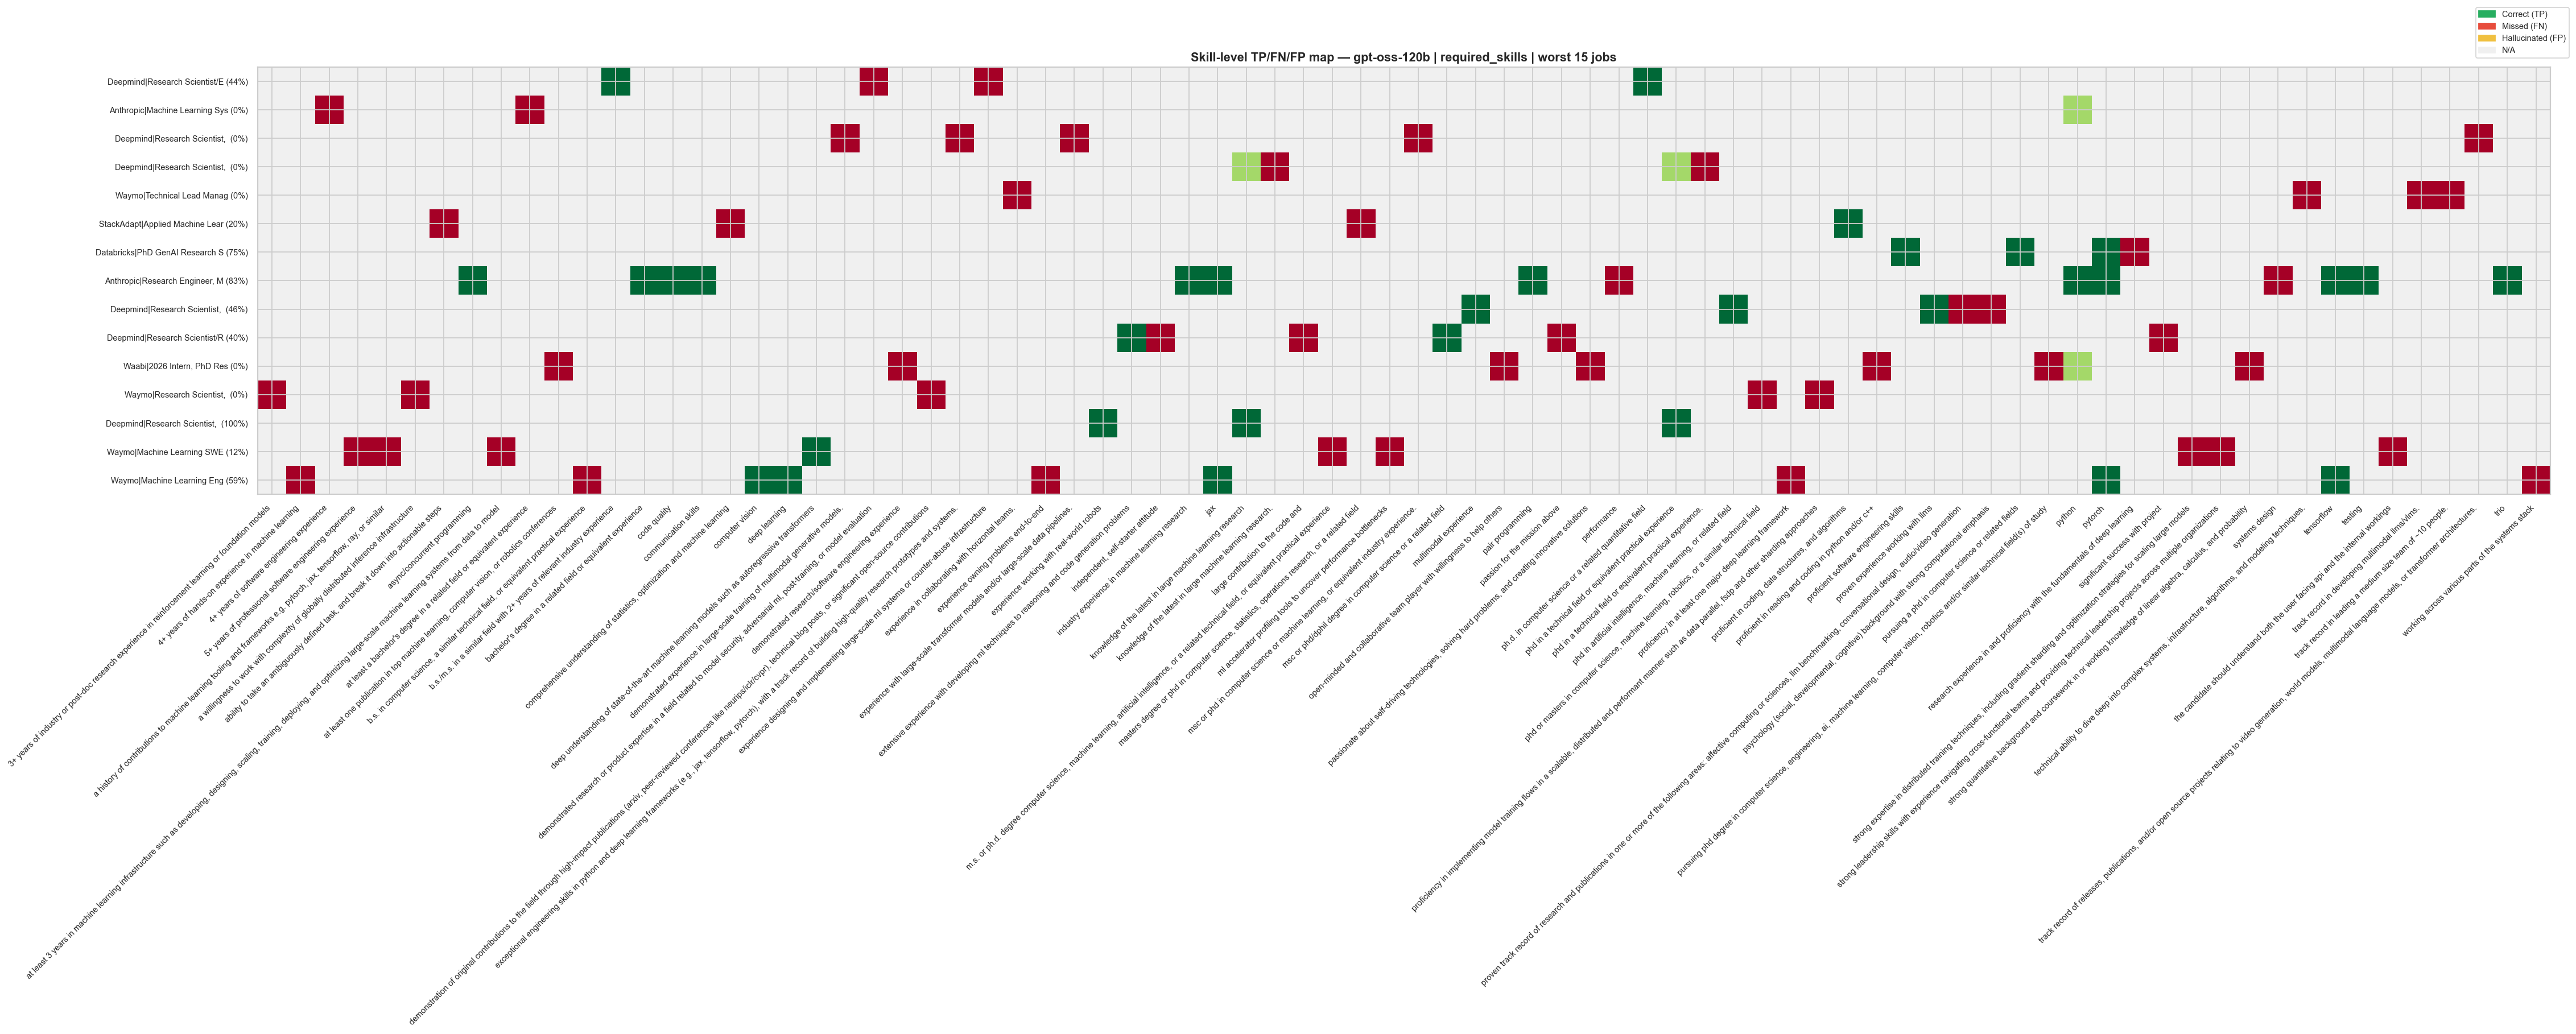

In [34]:
# Visualise the diff as a heatmap for the top-N worst jobs
def skill_diff_heatmap(n_jobs=10, field="required_skills", model=None):
    if model is None:
        model = FOCUS_MODEL
    worst_ids = focus_df.sort_values("overall").head(n_jobs)["job_id"].tolist()

    # Gather all unique teacher skills across these jobs
    all_t_skills = set()
    job_map = {j["id"]: j for j in JOBS}
    for jid in worst_ids:
        job = job_map.get(jid)
        if job:
            all_t_skills |= normalize_skills(parse_list(job["teacher"].get(field)))

    all_skills = sorted(all_t_skills)
    job_labels = []
    matrix = []
    for jid in worst_ids:
        job = job_map.get(jid)
        if not job:
            continue
        t_norm = normalize_skills(parse_list(job["teacher"].get(field)))
        s_data = job["students"].get(model, {})
        s_norm = (
            normalize_skills(parse_list(s_data.get("output", {}).get(field)))
            if s_data
            else set()
        )
        row = []
        for sk in all_skills:
            in_t, in_s = sk in t_norm, sk in s_norm
            if in_t and in_s:
                row.append(1)  # TP
            elif in_t:
                row.append(-1)  # FN (missed)
            elif in_s:
                row.append(0.4)  # FP (hallucinated)
            else:
                row.append(np.nan)
        matrix.append(row)
        score = s_data.get("scores", {}).get(field, 0) if s_data else 0
        job_labels.append(
            f"{job['company'][:15]}|{job['title'][:20]} ({score*100:.0f}%)"
        )

    mat = np.array(matrix, dtype=float)
    fig, ax = plt.subplots(
        figsize=(max(14, len(all_skills) * 0.5), max(5, n_jobs * 0.5))
    )
    cmap = plt.cm.get_cmap("RdYlGn").copy()
    cmap.set_bad(color="#f0f0f0")
    im = ax.imshow(mat, cmap=cmap, vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(len(all_skills)))
    ax.set_xticklabels(all_skills, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(job_labels)))
    ax.set_yticklabels(job_labels, fontsize=8)
    legend_els = [
        mpatches.Patch(color="#27ae60", label="Correct (TP)"),
        mpatches.Patch(color="#e74c3c", label="Missed (FN)"),
        mpatches.Patch(color="#f0c040", label="Hallucinated (FP)"),
        mpatches.Patch(color="#f0f0f0", label="N/A"),
    ]
    ax.legend(
        handles=legend_els, loc="upper right", bbox_to_anchor=(1.01, 1.15), fontsize=8
    )
    ax.set_title(
        f"Skill-level TP/FN/FP map — {short_name(model)} | {field} | worst {n_jobs} jobs",
        fontweight="bold",
    )
    plt.tight_layout()
    plt.show()


skill_diff_heatmap(n_jobs=15, field="required_skills")

---
## 10. Field-level Categorical Error Analysis

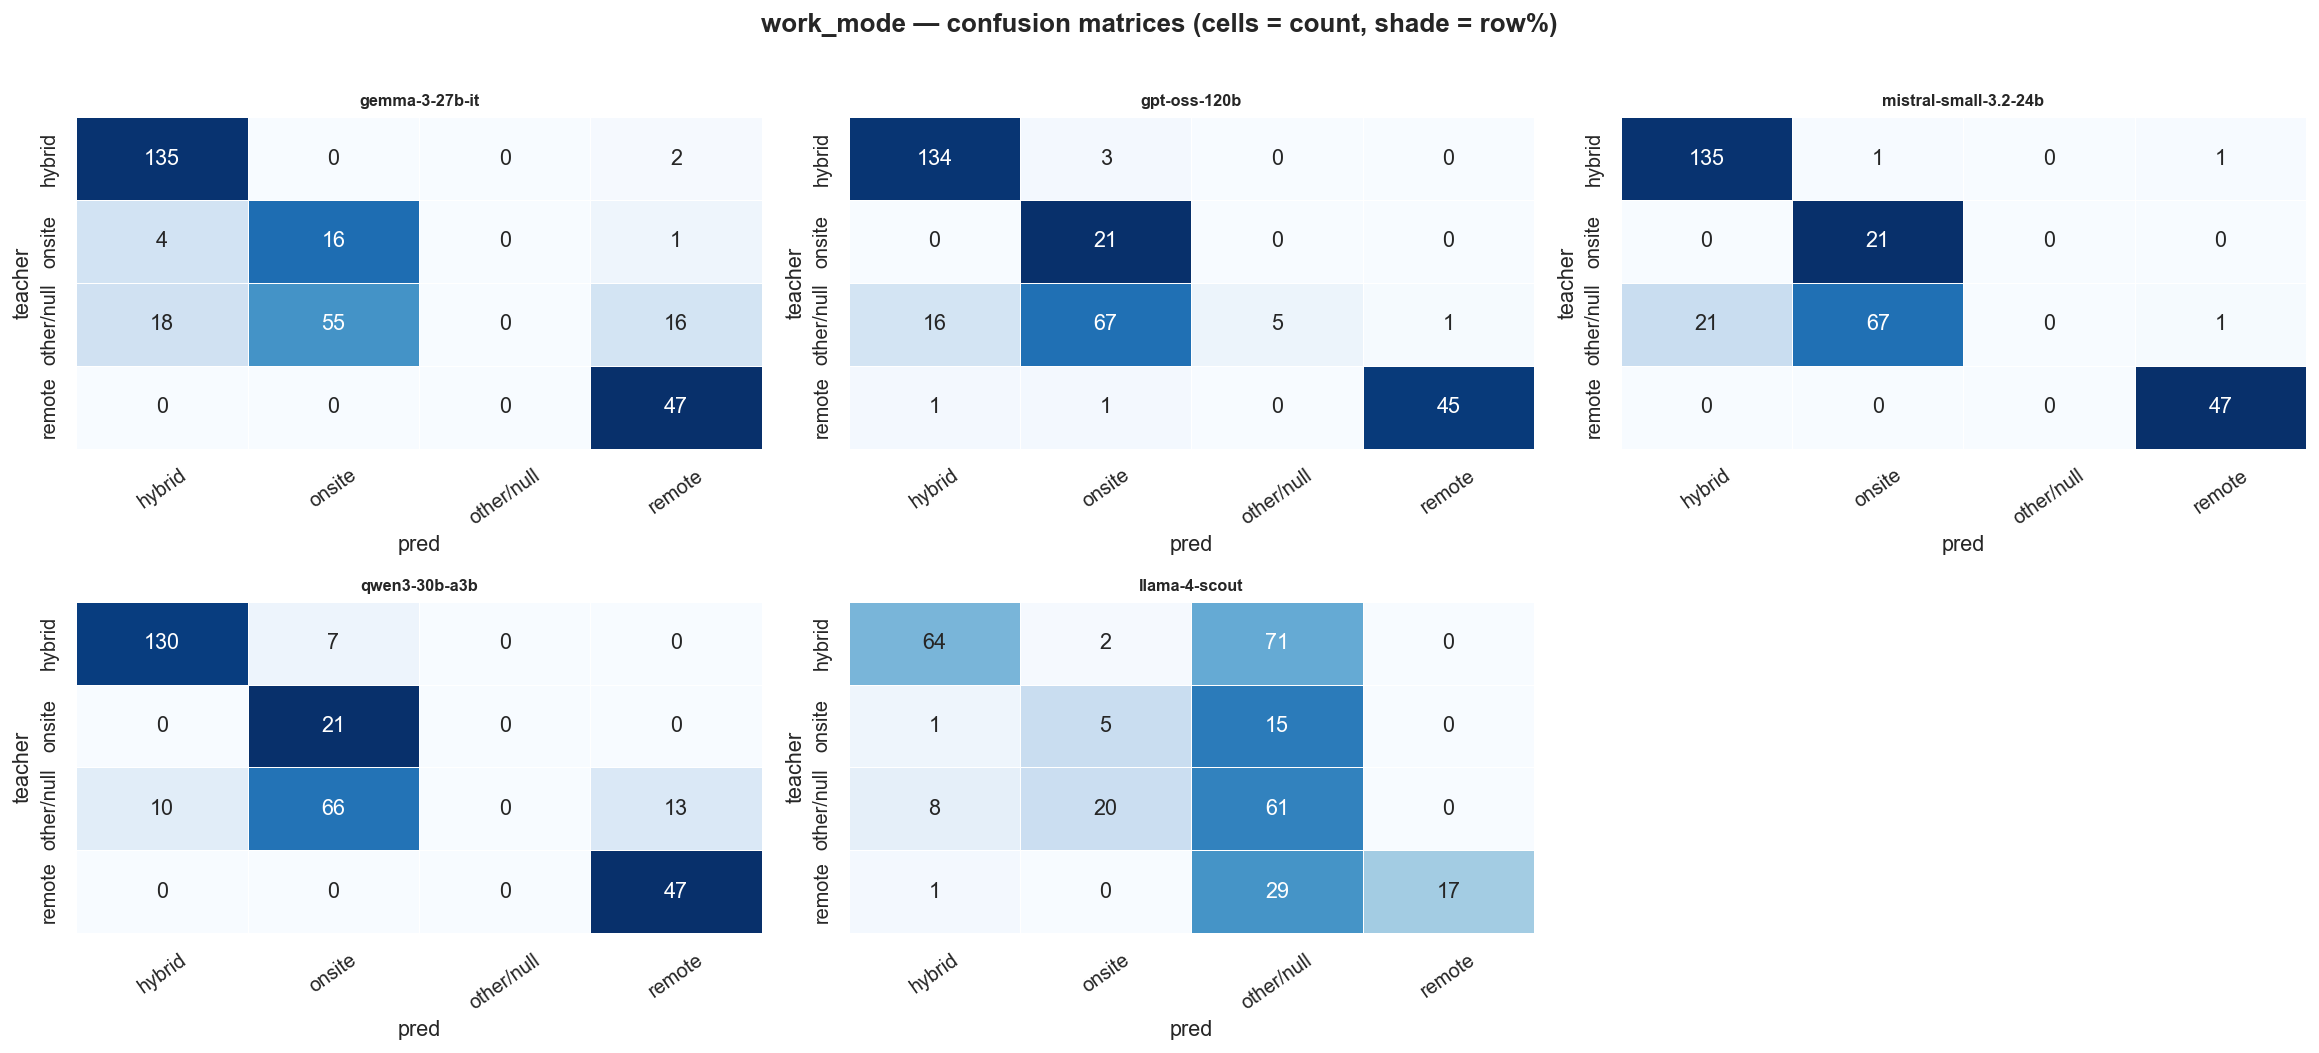

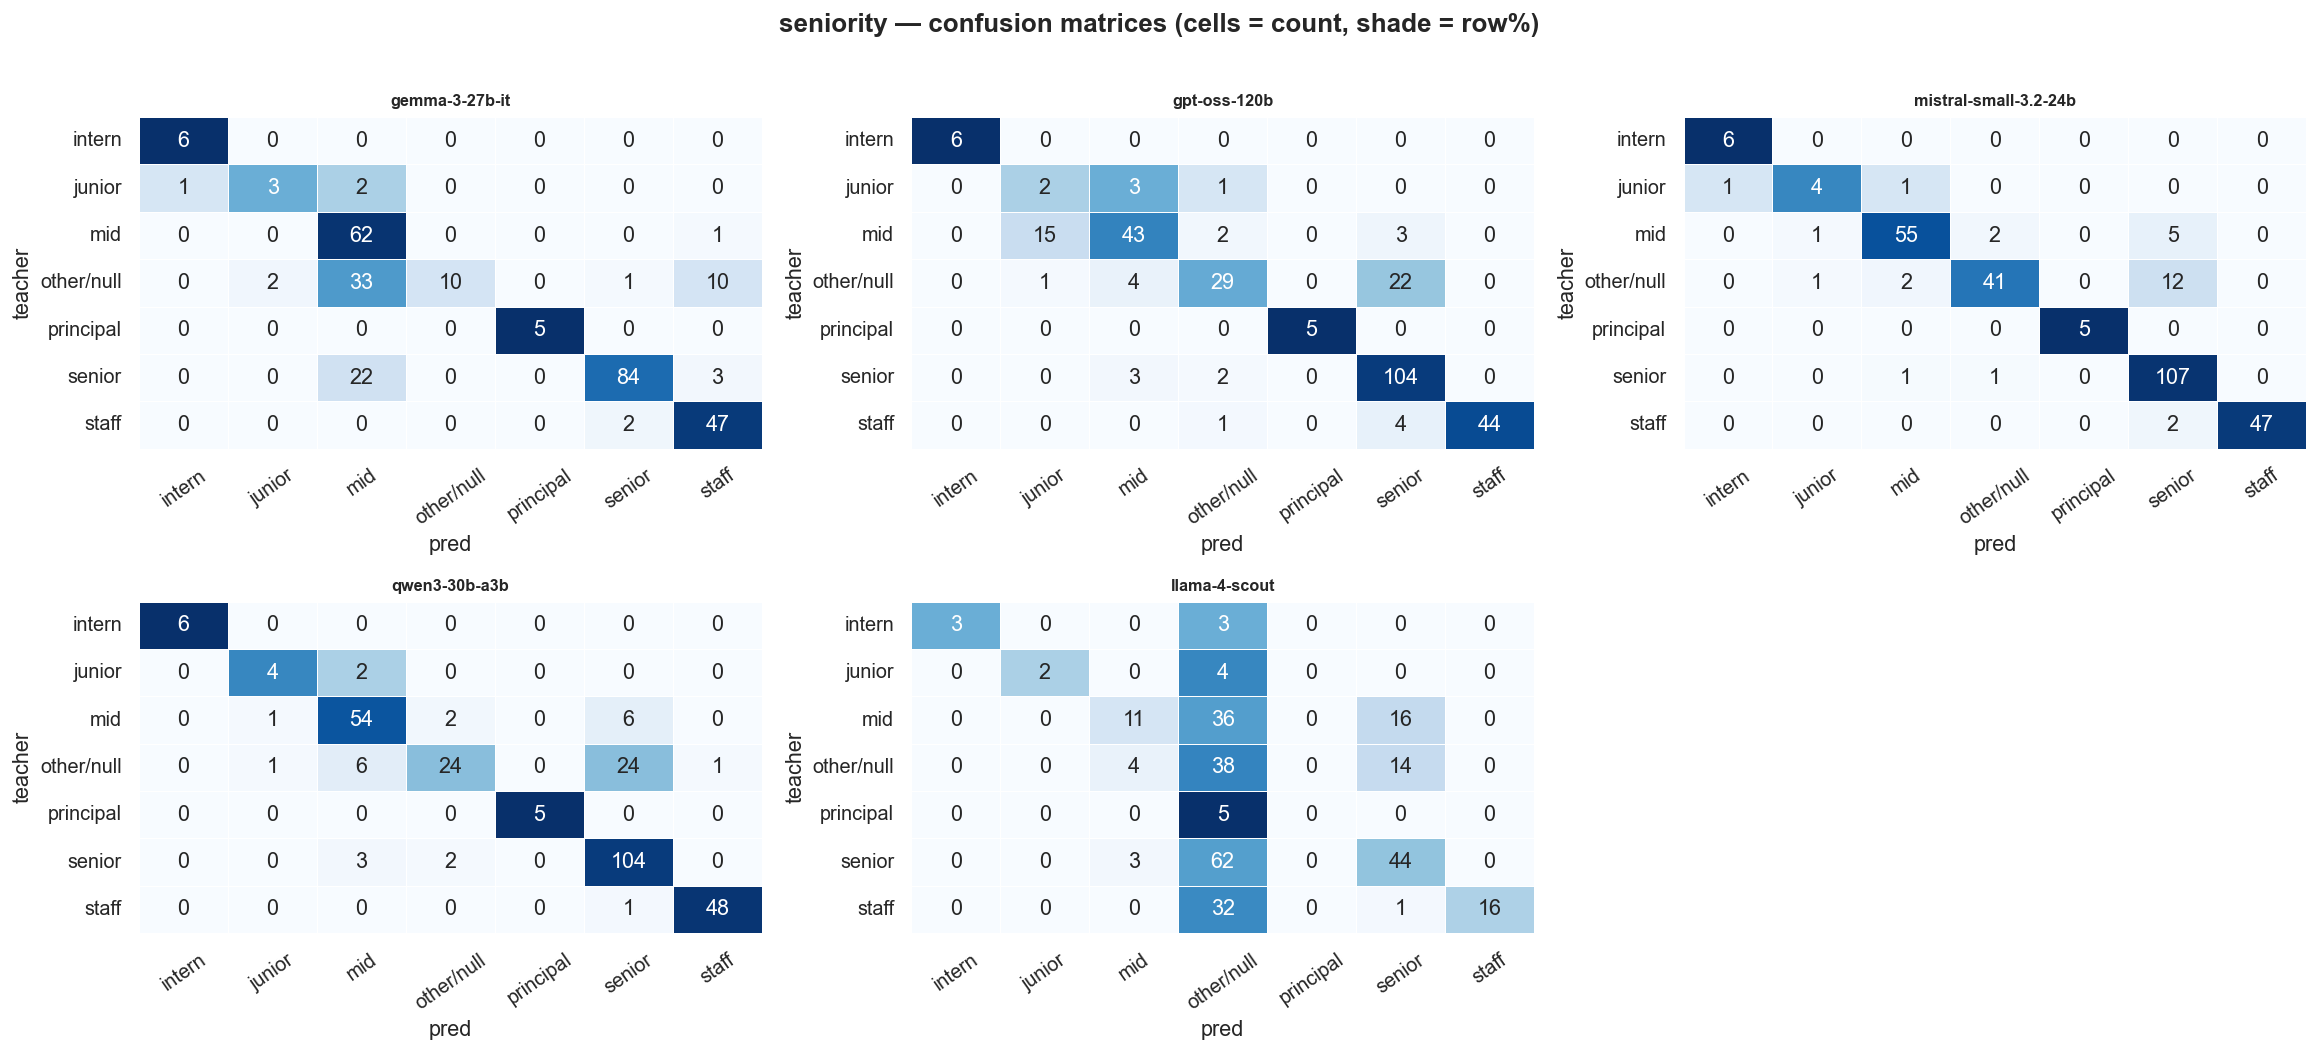

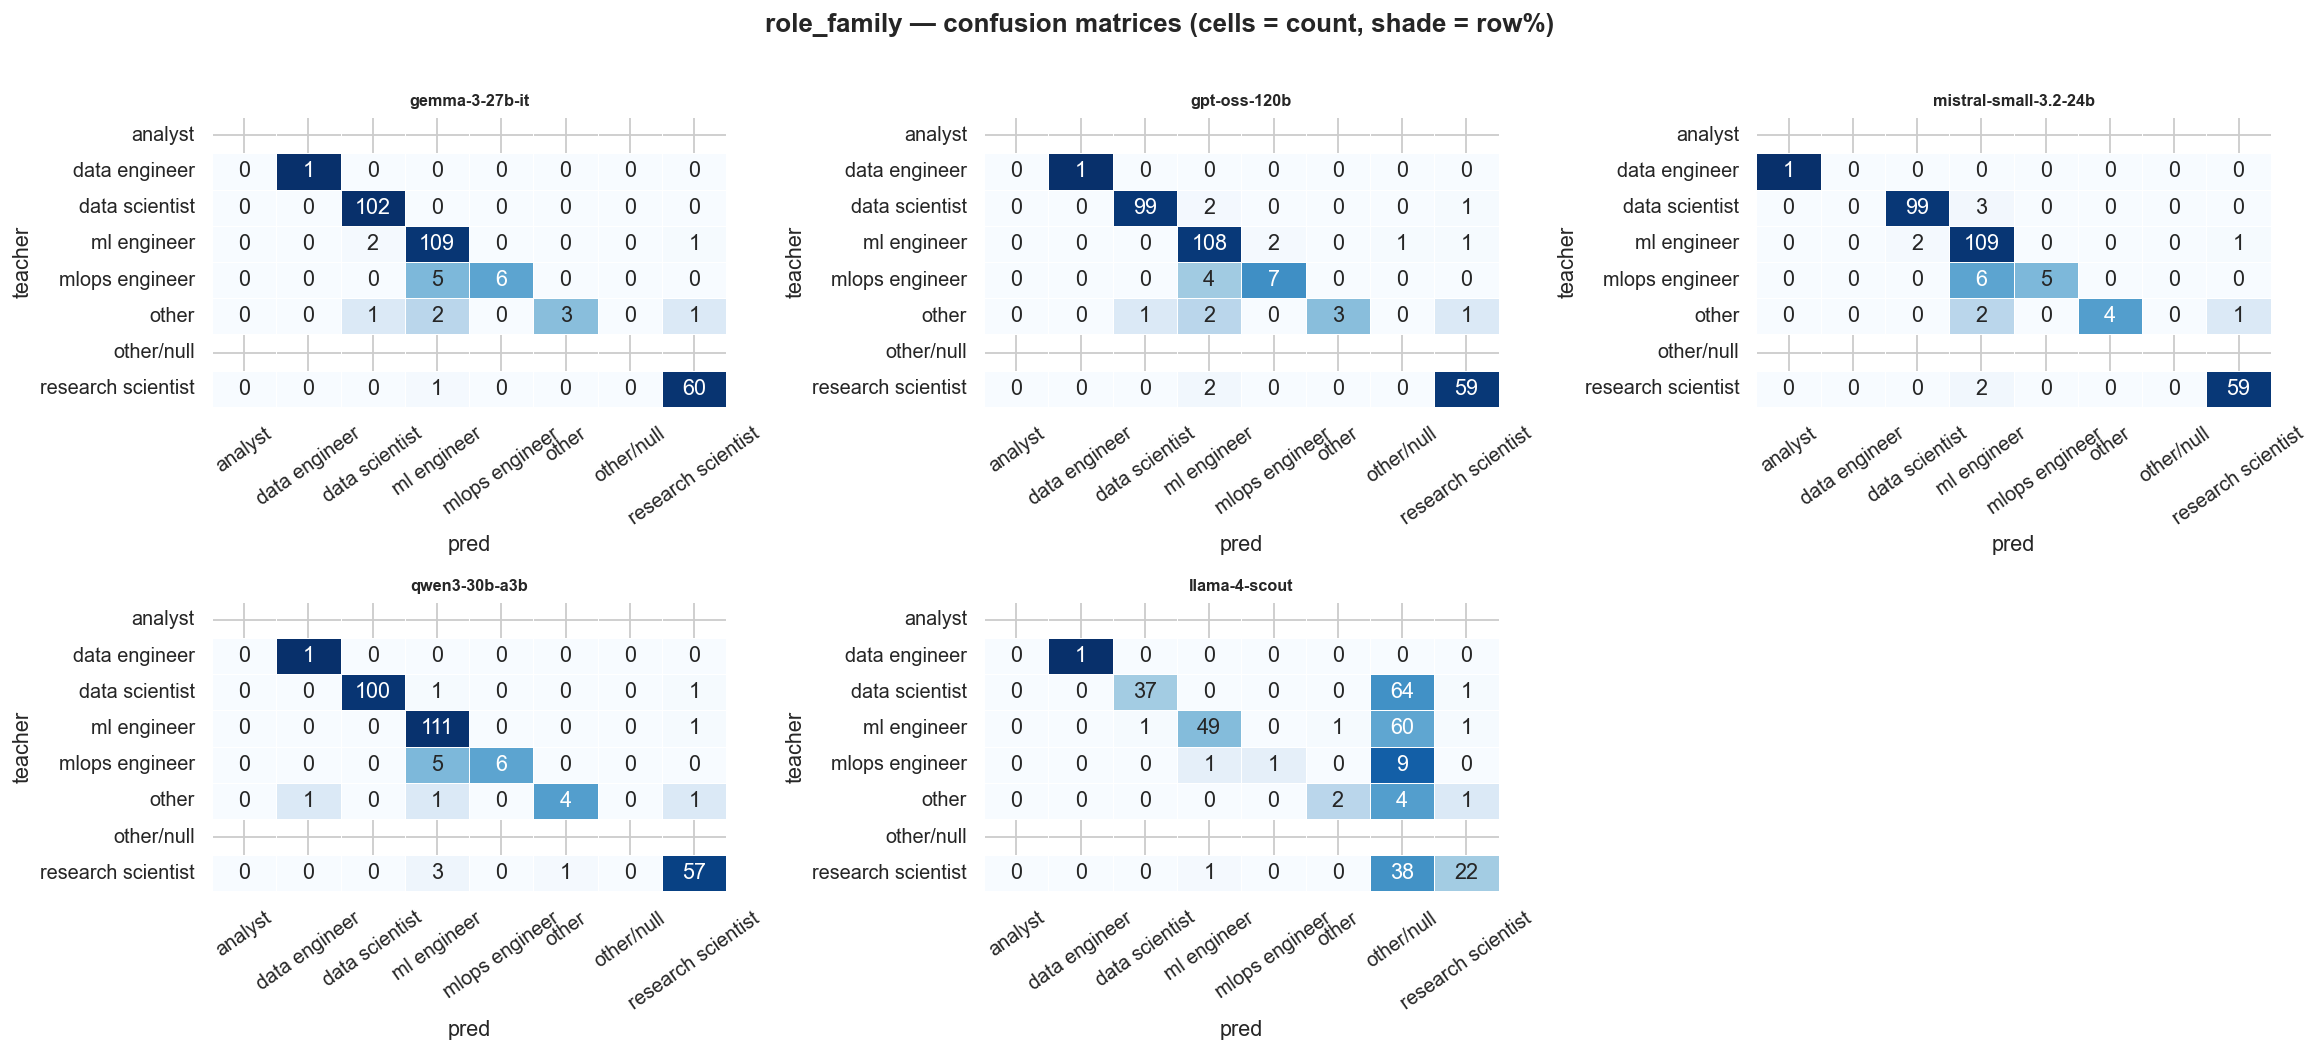

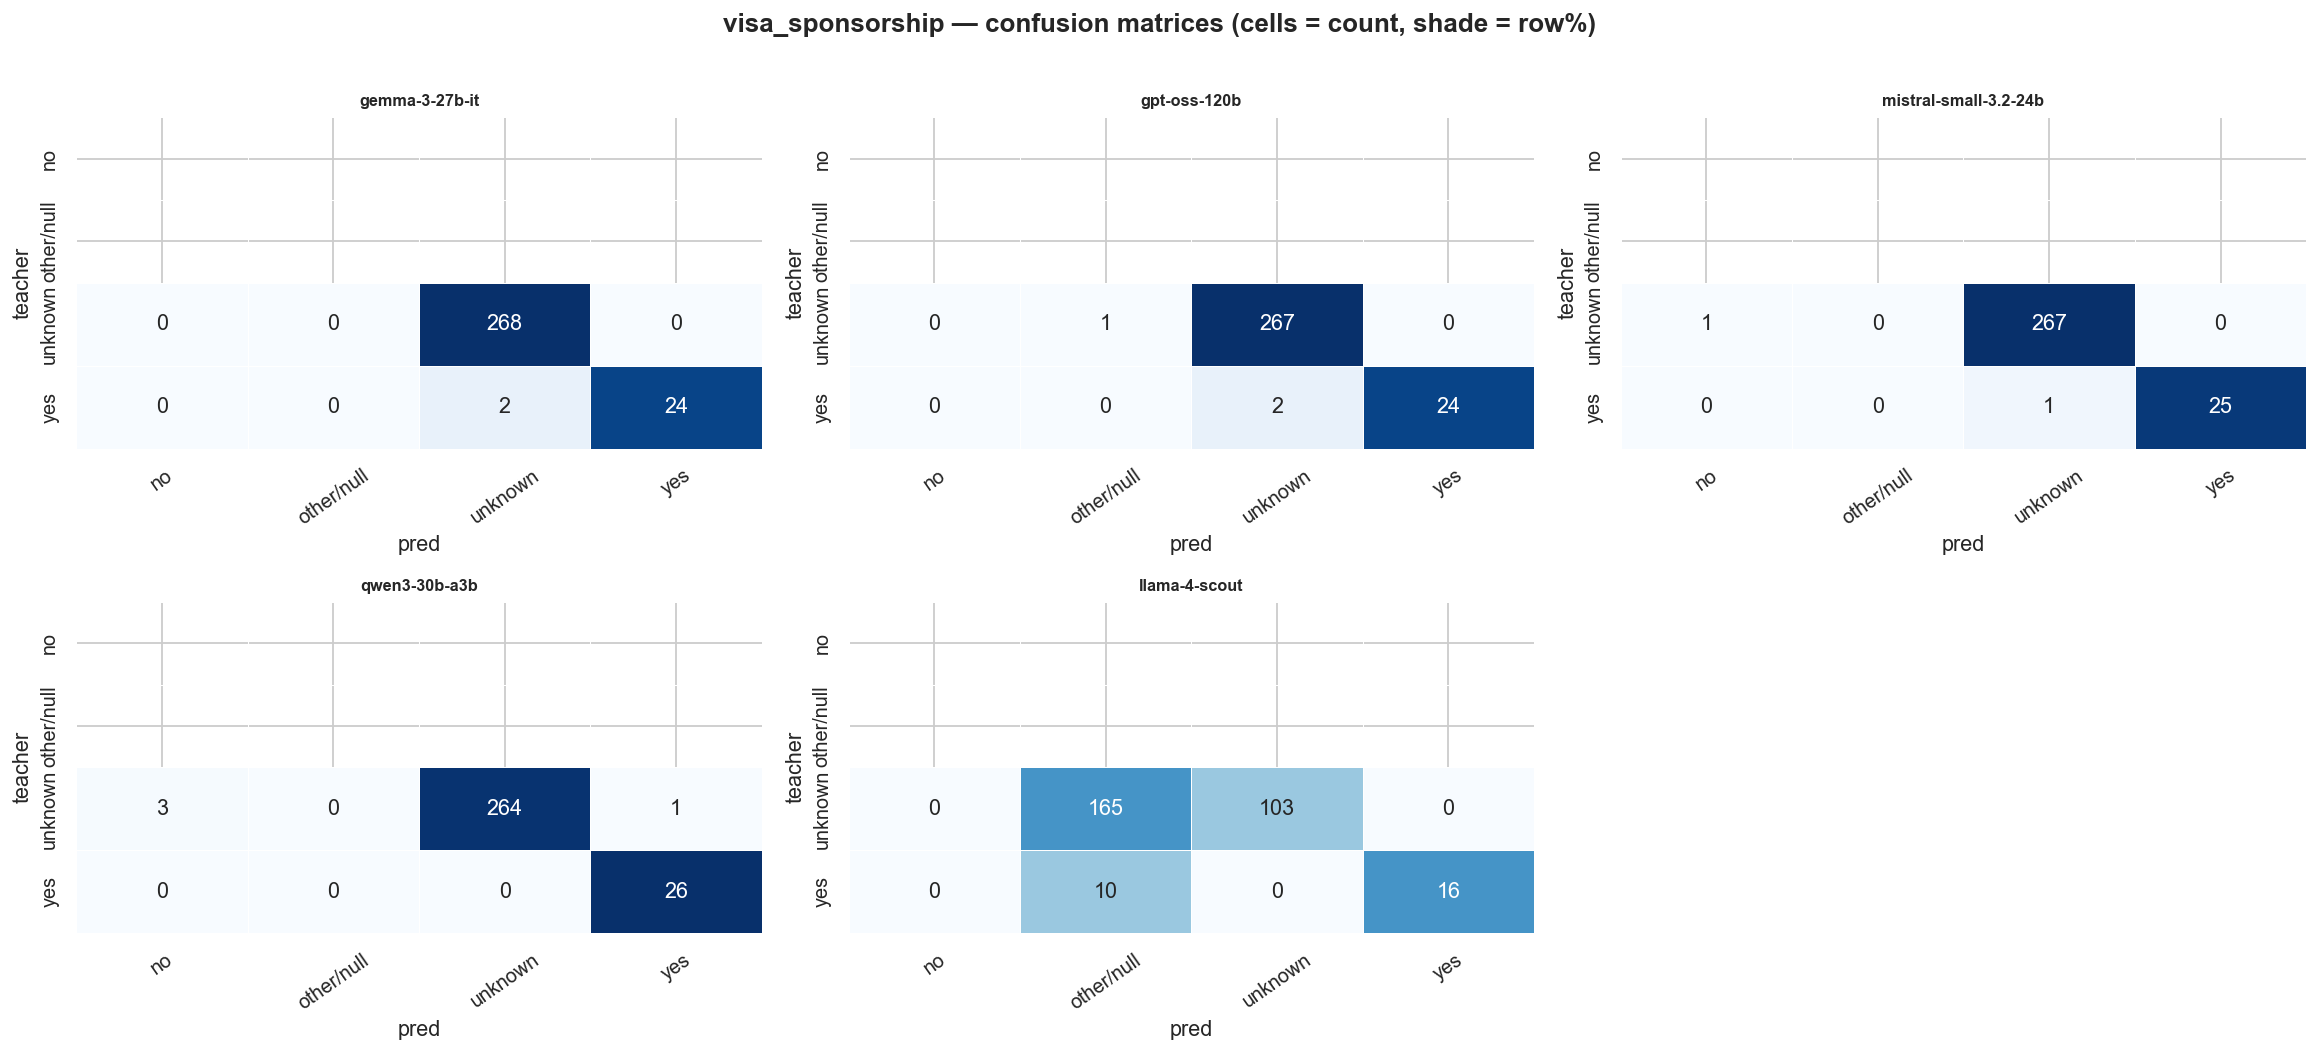

In [35]:
# For each categorical field: confusion matrix across models
CAT_FIELD_VALS = {
    "work_mode": ["remote", "hybrid", "onsite"],
    "seniority": ["intern", "junior", "mid", "senior", "staff", "principal"],
    "role_family": [
        "data scientist",
        "ml engineer",
        "mlops engineer",
        "data engineer",
        "research scientist",
        "analyst",
        "other",
    ],
    "visa_sponsorship": ["yes", "no", "unknown"],
}

for field, vals in CAT_FIELD_VALS.items():
    rows_cat = []
    for job in JOBS:
        t = str(job["teacher"].get(field, "")).lower().strip() or "null"
        if t not in vals:
            t = "other/null"
        for m in MODELS:
            student = job["students"].get(m, {})
            if not student or not student.get("output"):
                continue
            s = str(student["output"].get(field, "")).lower().strip() or "null"
            if s not in vals:
                s = "other/null"
            rows_cat.append({"model": short_name(m), "teacher": t, "pred": s})
    cat_df = pd.DataFrame(rows_cat)

    all_vals = sorted(set(cat_df["teacher"].unique()) | set(cat_df["pred"].unique()))
    ncols = min(3, len(MODELS))
    nrows = (len(MODELS) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
    axes = np.array(axes).flatten()

    for ax, m in zip(axes, [short_name(m) for m in MODELS]):
        m_df = cat_df[cat_df["model"] == m]
        mat = pd.crosstab(
            m_df["teacher"], m_df["pred"], rownames=["teacher"], colnames=["pred"]
        )
        mat = mat.reindex(index=all_vals, columns=all_vals, fill_value=0)
        mat_pct = mat.div(mat.sum(axis=1).replace(0, np.nan), axis=0) * 100
        sns.heatmap(
            mat_pct,
            annot=mat.values,
            fmt="d",
            cmap="Blues",
            vmin=0,
            vmax=100,
            linewidths=0.5,
            cbar=False,
            ax=ax,
        )
        ax.set_title(m, fontsize=9, fontweight="bold")
        ax.tick_params(axis="x", rotation=35)
    for ax in axes[len(MODELS) :]:
        ax.set_visible(False)
    fig.suptitle(
        f"{field} — confusion matrices (cells = count, shade = row%)",
        fontweight="bold",
        y=1.01,
    )
    plt.tight_layout()
    plt.show()

---
## 11. Interactive: Explore Any Job

Call `compare_job()` with any job index or ID to see the full diff.

In [36]:
# List jobs sorted by score for the focus model — pick an ID to inspect
focus_df.sort_values("overall")[
    ["job_id", "company", "title", "segment", "overall_pct"]
].head(30)

,job_id,company,title,segment,overall_pct
1023,db-234,Deepmind,"Research Scientist/Engineer, Model Threat Defense",red_flag,60.0
138,db-033,Anthropic,"Machine Learning Systems Engineer, RL Engineering",salary_disclosed,62.8
1031,db-236,Deepmind,"Research Scientist, Generative Worlds",core,63.1
1053,db-241,Deepmind,"Research Scientist, Robotics",salary_disclosed,63.5
695,db-158,Waymo,"Technical Lead Manager, LLM/VLM Foundation Model",salary_disclosed,63.5
46,db-011,StackAdapt,Applied Machine Learning Scientist,core,65.0
921,db-210,Databricks,PhD GenAI Research Scientist Intern,seniority_extreme,67.3
142,db-034,Anthropic,"Research Engineer, Machine Learning (Reinforce...",core,67.9
1058,db-242,Deepmind,"Research Scientist, Socioaffective Agents",salary_disclosed,68.4
1049,db-240,Deepmind,"Research Scientist/Research Engineer, AI for S...",salary_disclosed,68.5


In [37]:
# ── Customise these ───────────────────────────────────────────────────────────
JOB_TO_INSPECT = 0  # integer index OR job_id string e.g. 'db-001'
FIELD = "required_skills"  # or 'preferred_skills' / 'red_flags'
COMPARE_MODELS = MODELS  # or a subset e.g. [m for m in MODELS if 'gpt-oss' in m]
# ─────────────────────────────────────────────────────────────────────────────
compare_job(JOB_TO_INSPECT, FIELD, COMPARE_MODELS)


Job     : db-001 — Databricks | AI Engineer - FDE (Forward Deployed Engineer)
Segment : salary_disclosed
Field   : required_skills

TEACHER (22 skills):
   + amazon web services
   + dspy
   + evaluation
   + experience building genai applications
   + experience building production-grade machine learning deployments on aws, azure, or gcp
   + experience communicating and/or teaching technical concepts to non-technical and technical audiences alike
   + expertise in deploying production-grade genai applications
   + extensive years of hands-on industry data science experience
   + fine-tuning
   + google cloud
   + graduate degree in a quantitative discipline (computer science, engineering, statistics, operations research, etc.) or equivalent practical experience
   + huggingface
   + langchain
   + microsoft azure
   + multi-agent systems
   + optimizations
   + pandas
   + passion for collaboration, life-long learning, and driving business value through ai
   + pytorch
   + rag
   +

In [38]:
# Compare ALL fields for a single job across all models
def compare_all_fields(job_id_or_idx):
    if isinstance(job_id_or_idx, int):
        job = JOBS[job_id_or_idx]
    else:
        job = next((j for j in JOBS if j["id"] == job_id_or_idx), None)
    if job is None:
        print("Job not found")
        return

    print(f"\n{job['company']} | {job['title']}  ({job.get('segment','?')})\n")

    table_rows = []
    for f in SCORED_FIELDS:
        t_val = job["teacher"].get(f, "")
        if f in LIST_FIELDS:
            t_display = ", ".join(sorted(normalize_skills(parse_list(t_val))))[:80]
        else:
            t_display = str(t_val) if t_val is not None else "—"
        row = {"field": f, "teacher": t_display}
        for m in MODELS:
            s_data = job["students"].get(m, {})
            if not s_data or not s_data.get("output"):
                row[short_name(m)] = "N/A"
                continue
            s_val = s_data["output"].get(f, "")
            score = s_data["scores"].get(f, 0)
            if f in LIST_FIELDS:
                s_display = ", ".join(sorted(normalize_skills(parse_list(s_val))))[:60]
            else:
                s_display = str(s_val) if s_val is not None else "—"
            row[short_name(m)] = f"{s_display}  [{score*100:.0f}%]"
        table_rows.append(row)

    display_df = pd.DataFrame(table_rows).set_index("field")
    pd.set_option("display.max_colwidth", 90)
    return display_df


compare_all_fields(JOB_TO_INSPECT)


Databricks | AI Engineer - FDE (Forward Deployed Engineer)  (salary_disclosed)



,teacher,gemma-3-27b-it,gpt-oss-120b,mistral-small-3.2-24b,qwen3-30b-a3b,llama-4-scout
field,,,,,,
work_mode,remote,remote [100%],remote [100%],remote [100%],remote [100%],remote [100%]
canada_eligible,unknown,unknown [100%],no [25%],no [25%],no [25%],no [25%]
seniority,senior,mid [75%],— [0%],senior [100%],— [0%],senior [100%]
role_family,ml engineer,ml engineer [100%],ml engineer [100%],ml engineer [100%],ml engineer [100%],ml engineer [100%]
visa_sponsorship,unknown,unknown [100%],unknown [100%],no [25%],unknown [100%],unknown [100%]
required_skills,"amazon web services, dspy, evaluation, experience building genai applications, e","amazon web services, deploying production-grade genai applic [78%]","amazon web services, dspy, genai application development, go [53%]","experience building genai applications, including rag, multi [28%]","experience building genai applications, including rag, multi [28%]","experience building genai applications, experience communica [37%]"
preferred_skills,"apache spark, experience using the databricks intelligence platform","apache spark™, databricks intelligence platform [0%]","apache spark, databricks intelligence platform [50%]",experience using the databricks intelligence platform and ap [0%],experience using the databricks intelligence platform and ap [0%],experience using the databricks intelligence platform and ap [0%]
red_flags,,[100%],[100%],it is within employer's discretion whether to apply for a u. [0%],[100%],if access to export-controlled technology or source code is [0%]
years_exp_min,—,— [100%],— [100%],— [100%],— [100%],— [100%]
